# Trabajo Práctico de NLP
# Cabeza de Equipo: un asistente con RAG sobre psicología del deporte

**Integrantes:** _(completar)_
**Fecha:** _(completar)_

---

## Resumen

Este trabajo implementa y evalúa un sistema de **Retrieval-Augmented Generation** en español sobre
un corpus de cinco artículos científicos de acceso abierto sobre psicología del deporte aplicada
al fútbol formativo.

El asistente está orientado al **futbolista juvenil**: la premisa es que el acompañamiento
psicológico profesional está fuera del alcance económico de la mayoría, mientras que la evidencia
científica sobre esas mismas cuestiones es pública pero está escrita en un registro inaccesible
para un adolescente. El sistema busca hacer de puente.

La evaluación se organiza en dos conjuntos de preguntas con funciones distintas: uno anotado, que
permite medir el retrieval con `hit@k`, y otro escrito en el registro de un jugador de 16 años,
que permite evaluar el sistema como producto. Esa separación resultó central para los hallazgos
del trabajo.

## Organización del notebook

| Fase | Contenido |
|---|---|
| 0 | Instalación y configuración |
| 1 | Corpus: carga, extracción, limpieza, estadísticas y dos estrategias de chunking |
| 2 | Embeddings e índice vectorial FAISS |
| 3 | Evaluación del retrieval: `hit@k`, `precision@k` y `MRR` |
| 4 | Generación con LLM: comparación CON RAG vs SIN RAG |
| 5 | Iteración: corrección del pipeline a partir del análisis de errores |
| 6 | Reporte final |

## Requisitos de ejecución

El notebook corre de punta a punta en Google Colab con entorno **GPU T4**
(`Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`). Los cinco PDFs del corpus se suben
cuando lo solicita la celda 1.2. Los modelos empleados —`paraphrase-multilingual-mpnet-base-v2`
para embeddings y `Qwen2.5-1.5B-Instruct` para generación— son de acceso abierto y se descargan
sin autenticación.

> **Alcance.** El sistema es una herramienta de divulgación y orientación. No reemplaza el
> acompañamiento de un profesional de la salud mental.

---

# Fase 0 — Setup

In [1]:
!pip install -q pymupdf sentence-transformers faiss-cpu transformers accelerate

print("Instalacion terminada.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 54.5 MB/s eta 0:00:00
Instalacion terminada.


In [2]:
import os, re, json, textwrap, statistics, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Configuracion central: todos los parametros del TP en un solo lugar, asi
# probar otra configuracion es cambiar un numero y volver a ejecutar.
# ---------------------------------------------------------------------------
CONFIG = {
    # Fase 1 - chunking
    "fixed_size":      800,   # caracteres por chunk en la estrategia A
    "fixed_overlap":   100,   # solapamiento entre chunks consecutivos
    "par_max":         800,   # tamano maximo de un chunk paragraph-aware
    "par_min":         200,   # descarta fragmentos mas cortos que esto

    # Fase 2 - embeddings
    "embedder": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",

    # Fase 3 - evaluacion
    "k_values": [1, 3, 5],

    # Fase 4 - generacion
    "llm":        "Qwen/Qwen2.5-1.5B-Instruct",
    "k_rag":      4,     # cuantos chunks recibe el LLM como contexto
    "max_tokens": 350,

    "seed": 42,
}

np.random.seed(CONFIG["seed"])

DIR_PDFS = "pdfs"
os.makedirs(DIR_PDFS, exist_ok=True)

# Paleta de graficos (par validado para daltonismo)
C_AZUL, C_NARANJA = "#2a78d6", "#eb6834"
C_TINTA, C_MUTED, C_GRILLA = "#0b0b0b", "#898781", "#e1e0d9"

pd.set_option("display.max_colwidth", 90)
print("Configuracion cargada.")

Configuracion cargada.


---

# Fase 1 — Corpus y chunking

## 1.1 Composición del corpus

El corpus está formado por cinco artículos científicos en español, de acceso abierto, sobre
psicología del deporte aplicada al fútbol formativo. Cada artículo constituye **un documento**:
es la unidad de trazabilidad con la que se anotan las preguntas de evaluación y se mide el `hit@k`.

| id | Artículo | Eje temático |
|---|---|---|
| `iberoam_intervencion` | Navarrón et al. (2017). *Implementación de una intervención psicológica en fútbol base, satisfacción subjetiva de los deportistas y experiencias de pasión, competencia percibida y compromiso deportivo*. Rev. Iberoamericana de Psicología del Ejercicio y el Deporte, 12(1) | Habilidades psicológicas |
| `cpd_burnout` | De Francisco et al. (2009). *Propiedades psicométricas preliminares de la versión española del Athlete Burnout Questionnaire en una muestra de jóvenes futbolistas*. Cuadernos de Psicología del Deporte, 9(2) | Burnout |
| `anales_bayesiano` | Garcia-Mas et al. (2015). *Análisis bayesiano de la motivación, el clima motivacional y la ansiedad en jóvenes jugadores de equipo*. Anales de Psicología, 31(1) | Motivación y clima motivacional |
| `sportis_motiv_ansied` | Arroyo del Bosque et al. (2025). *Motivación y ansiedad en el fútbol formativo: claves para el desarrollo psicológico en categorías alevín e infantil*. Sportis, 11(3) | Ansiedad precompetitiva |
| `ariza_fisio_psico_futbol` | León Ariza et al. (2011). *Demandas fisiológicas y psicológicas en el fútbol*. Cuerpo, Cultura y Movimiento, 1(2) | Demandas de la competencia |

### Criterios de selección

**Desconocimiento por parte del modelo generador.** Qwen2.5-1.5B-Instruct es un modelo pequeño y
estos artículos son material de nicho. Ante una pregunta sobre la duración de una intervención
concreta, el modelo no tiene forma de saber la respuesta pero igualmente produce una cifra. Esto
hace que la comparación CON RAG vs SIN RAG de la Fase 4 muestre un contraste medible, a diferencia
de un corpus sobre temas ampliamente representados en el pre-entrenamiento.

**Estructura favorable a la comparación de chunkings.** Un artículo científico presenta bloques
semánticos explícitos y estables —Resumen, Introducción, Método (Participantes, Instrumentos,
Procedimiento), Resultados, Discusión—, lo que permite contrastar una estrategia de segmentación
que los respeta contra una que los ignora.

**Verificabilidad de las respuestas.** Un tamaño muestral, un rango etario o el nombre de un
instrumento están en el documento o no están. Esto permite anotar el conjunto de evaluación sin
ambigüedad y clasificar las alucinaciones sin discusión.

### Nota sobre el solapamiento entre documentos

Dos artículos del corpus describen intervenciones psicológicas: Navarrón et al. reportan un
programa de 12 semanas con 12 jugadores de un club local, y León Ariza et al. revisan demandas de
la competencia. Como varios documentos reportan tamaños muestrales, las preguntas de evaluación
debieron redactarse anclándose a datos que aparecen en un único artículo, para que `hit@k` mida
efectivamente la recuperación y no penalice al sistema por acertar en un documento alternativo
igualmente válido.

El corpus cumple los requisitos del enunciado: **176.872 caracteres** tras la limpieza (2,9 veces
el mínimo de 60.000) distribuidos en **5 documentos**.

In [3]:
# ---------------------------------------------------------------------------
# CORPUS. El campo "archivo" tiene que coincidir con el nombre del PDF subido.
# Para sumar un documento: agregar una entrada aca y subir su PDF.
# ---------------------------------------------------------------------------
CORPUS = [
    {"id": "iberoam_intervencion",
     "archivo": "iberoam_intervencion.pdf",
     "titulo": "Implementacion de una intervencion psicologica en futbol base, satisfaccion "
               "subjetiva de los deportistas y experiencias de pasion, competencia percibida "
               "y compromiso deportivo",
     "autores": "Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017)",
     "fuente": "Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69",
     "eje": "B"},

    {"id": "cpd_burnout",
     "archivo": "cpd_burnout.pdf",
     "titulo": "Propiedades psicometricas preliminares de la version espanola del Athlete "
               "Burnout Questionnaire en una muestra de jovenes futbolistas",
     "autores": "De Francisco, Arce, Andrade, Arce y Raedeke (2009)",
     "fuente": "Cuadernos de Psicologia del Deporte, 9(2), 45-56",
     "eje": "D"},

    {"id": "anales_bayesiano",
     "archivo": "anales_bayesiano.pdf",
     "titulo": "Analisis bayesiano de la motivacion, el clima motivacional y la ansiedad en "
               "jovenes jugadores de equipo",
     "autores": "Garcia-Mas, Fuster-Parra, Ponseti, Palou, Olmedilla y Cruz (2015)",
     "fuente": "Anales de Psicologia, 31(1), 355-366",
     "eje": "C"},

    {"id": "sportis_motiv_ansied",
     "archivo": "sportis_motiv_ansied.pdf",
     "titulo": "Motivacion y ansiedad en el futbol formativo: claves para el desarrollo "
               "psicologico en categorias alevin e infantil",
     "autores": "Arroyo del Bosque, Cook Vaquero, Moral Garcia y Amatria Jimenez (2025)",
     "fuente": "Sportis Sci J, 11(3), 1-26",
     "eje": "A"},

    # A diferencia de los otros cuatro, este es un articulo de REVISION (no un estudio
    # empirico propio): sintetiza hallazgos fisiologicos y psicologicos de decenas de
    # estudios previos. Por eso va en un eje propio (E) en vez de forzarlo dentro de B.
    {"id": "ariza_fisio_psico_futbol",
     "archivo": "ariza_fisio_psico_futbol.pdf",
     "titulo": "Demandas fisiologicas y psicologicas en el futbol",
     "autores": "Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011)",
     "fuente": "Cuerpo, Cultura y Movimiento, 1(2), 41-55",
     "eje": "E"},
]

print(f"{len(CORPUS)} documentos definidos.")
if len(CORPUS) < 5:
    print(f"ATENCION: el enunciado pide minimo 5 documentos. Faltan {5 - len(CORPUS)}.")
pd.DataFrame(CORPUS)[["id", "eje", "autores", "fuente"]]

5 documentos definidos.


,id,eje,autores,fuente
0,iberoam_intervencion,B,"Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017)","Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69"
1,cpd_burnout,D,"De Francisco, Arce, Andrade, Arce y Raedeke (2009)","Cuadernos de Psicologia del Deporte, 9(2), 45-56"
2,anales_bayesiano,C,"Garcia-Mas, Fuster-Parra, Ponseti, Palou, Olmedilla y Cruz (2015)","Anales de Psicologia, 31(1), 355-366"
3,sportis_motiv_ansied,A,"Arroyo del Bosque, Cook Vaquero, Moral Garcia y Amatria Jimenez (2025)","Sportis Sci J, 11(3), 1-26"
4,ariza_fisio_psico_futbol,E,"Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011)","Cuerpo, Cultura y Movimiento, 1(2), 41-55"


## 1.2 Carga de los documentos

Los cinco PDFs se cargan desde el entorno local. El nombre de cada archivo debe coincidir con el
campo `archivo` declarado en `CORPUS`, que es lo que vincula cada PDF con sus metadatos.

In [4]:
def pdfs_presentes():
    return {d["archivo"]: os.path.join(DIR_PDFS, d["archivo"])
            for d in CORPUS
            if os.path.exists(os.path.join(DIR_PDFS, d["archivo"]))}

if len(pdfs_presentes()) < len(CORPUS):
    try:
        from google.colab import files
        print("Subi los PDFs del corpus:\n")
        subidos = files.upload()
        for nombre in subidos:
            os.replace(nombre, os.path.join(DIR_PDFS, nombre))
        print()
    except ImportError:
        print(f"Fuera de Colab: copiar los PDFs a ./{DIR_PDFS}/\n")

documentos, faltantes = [], []
for d in CORPUS:
    ruta = os.path.join(DIR_PDFS, d["archivo"])
    if os.path.exists(ruta):
        d["ruta"] = ruta
        documentos.append(d)
        print(f"  OK     {d['id']:24s} {os.path.getsize(ruta)//1024:5d} KB")
    else:
        faltantes.append(d["archivo"])
        print(f"  FALTA  {d['id']:24s} -> {d['archivo']}")

print(f"\n{len(documentos)} de {len(CORPUS)} documentos cargados.")
if faltantes:
    print("Archivos que faltan subir:", ", ".join(faltantes))

  OK     iberoam_intervencion       366 KB
  OK     cpd_burnout                141 KB
  OK     anales_bayesiano           416 KB
  OK     sportis_motiv_ansied       667 KB
  OK     ariza_fisio_psico_futbol   282 KB

5 de 5 documentos cargados.


## 1.3 Extracción del texto

La extracción toma dos decisiones que condicionan el resto del pipeline.

**Extracción por bloques en lugar de texto plano.** Solicitar el texto corrido de cada página
devuelve líneas, no párrafos, y con ello se pierde la estructura que la estrategia de chunking
por párrafos necesita para existir. Empleamos `get_text("blocks")` de PyMuPDF, que devuelve los
bloques detectados en el layout junto con sus coordenadas. Esto aporta dos ventajas: los bloques
aproximan párrafos reales, y las coordenadas permiten descartar encabezados y pies de página por
su posición —el 7% superior e inferior de cada página, donde se ubican el nombre de la revista,
el DOI y la numeración.

**Reconstrucción de párrafos en documentos fragmentados.** Algunos PDFs devuelven un bloque por
renglón en lugar de uno por párrafo. En este corpus ocurre en dos de los cinco documentos: el
artículo de Sportis se extrae en 755 bloques de unos 80 caracteres de mediana. Sin corregirlo, la
estrategia paragraph-aware agruparía renglones sueltos y la comparación entre estrategias mediría
ruido en lugar de estructura.

La detección se basa en la mediana de longitud de los bloques: por debajo de 150 caracteres se
asume extracción a nivel de línea. La reconstrucción aplica una regla conservadora —un párrafo
nuevo comienza únicamente cuando el bloque anterior cierra oración con `.`, `!`, `?`, `:` o `;`
y el siguiente arranca en mayúscula—; en cualquier otro caso se asume que la oración continúa y
los bloques se unen. En el artículo de Sportis esto reconstruye 127 párrafos de 418 caracteres de
mediana, un tamaño de párrafo plausible.

In [5]:
import pymupdf

def extraer_bloques(ruta, margen_sup=0.07, margen_inf=0.93):
    """Extrae bloques de texto de un PDF descartando headers/footers por posicion."""
    doc = pymupdf.open(ruta)
    bloques_texto = []
    for pagina in doc:
        alto = pagina.rect.height
        bloques = sorted(pagina.get_text("blocks"), key=lambda b: (round(b[1] / 10), b[0]))
        for b in bloques:
            y0, y1, texto, tipo = b[1], b[3], b[4], b[6]
            if tipo != 0:                                     # 0 = texto, 1 = imagen
                continue
            if y1 < alto * margen_sup or y0 > alto * margen_inf:
                continue                                      # header / footer
            texto = texto.strip()
            if not texto or re.fullmatch(r"[\d\s\-–—]+", texto):
                continue                                      # numero de pagina suelto
            bloques_texto.append(texto)
    doc.close()
    return bloques_texto


def reunir_lineas(bloques, umbral_mediana=150):
    """Si el PDF devolvio bloques a nivel de linea, los reagrupa en parrafos."""
    largos = [len(b) for b in bloques]
    if not largos or statistics.median(largos) >= umbral_mediana:
        return bloques, False                                 # ya venian como parrafos

    parrafos, buffer = [], ""
    for b in bloques:
        b = b.replace("\n", " ").strip()
        if not buffer:
            buffer = b
        elif re.search(r"[.!?:;]\s*$", buffer) and re.match(r"[A-ZÁÉÍÓÚÑ¿¡«\"(]", b):
            parrafos.append(buffer)                           # el anterior cerro oracion
            buffer = b
        else:
            buffer = buffer + " " + b                         # la oracion continua
    if buffer:
        parrafos.append(buffer)
    return parrafos, True


for doc in documentos:
    bloques = extraer_bloques(doc["ruta"])
    mediana_antes = statistics.median([len(b) for b in bloques]) if bloques else 0
    parrafos, reunido = reunir_lineas(bloques)
    doc["parrafos_crudos"] = parrafos
    doc["texto_crudo"] = "\n\n".join(parrafos)
    nota = (f"reconstruido (mediana {mediana_antes:.0f} -> "
            f"{statistics.median([len(p) for p in parrafos]):.0f} chars)") if reunido else "ok"
    print(f"  {doc['id']:24s} {len(bloques):4d} bloques -> {len(parrafos):4d} parrafos   {nota}")

  iberoam_intervencion      242 bloques ->  242 parrafos   ok
  cpd_burnout               135 bloques ->  135 parrafos   ok
  anales_bayesiano          163 bloques ->  163 parrafos   ok
  sportis_motiv_ansied      755 bloques ->  127 parrafos   reconstruido (mediana 80 -> 418 chars)
  ariza_fisio_psico_futbol  152 bloques ->   65 parrafos   reconstruido (mediana 75 -> 391 chars)


## 1.4 Limpieza

Se aplican cinco operaciones, cada una dirigida a un problema específico del texto extraído de
artículos académicos en PDF.

**1. Encabezados y pies de página residuales.** Algunos quedan dentro del área de texto y escapan
al filtro posicional. Se detectan por frecuencia: un bloque breve que aparece tres o más veces en
el mismo documento es un encabezado repetido, no contenido.

**2. Sección de referencias.** Es la limpieza de mayor impacto cuantitativo. Un artículo contiene
entre 40 y 80 referencias bibliográficas —cientos de líneas de apellidos, años y títulos— que, de
ingresar al índice, compiten con el contenido real en cualquier consulta que mencione un autor o
un concepto.

La detección no es trivial. Buscar el encabezado *Referencias* al inicio de línea falla en los
documentos que pasaron por la reconstrucción de párrafos, donde queda unido al final del párrafo
anterior; en este corpus eso ocurre en el artículo más extenso, y omitirlo dejaba entrar unos
14.000 caracteres de bibliografía. La solución adoptada busca el término en cualquier posición y
confirma que se trata del encabezado real inspeccionando lo que sigue: una bibliografía comienza
con un patrón `Apellido, N.` o con un año entre paréntesis. Esto descarta menciones incidentales
como "utilice la siguiente referencia" o "punto de referencia". Se exige además que aparezca
pasado el 40% del documento.

**3. Separación de secciones multilingües.** Varias revistas publican el resumen en inglés, y las
iberoamericanas también en portugués; dos artículos de este corpus incluyen los tres idiomas. El
PDF suele devolver el RESUMEN, el ABSTRACT y el RESUMO en un mismo bloque, de modo que no es
posible descartarlos por bloque sin perder el texto en español. Se los separa previamente cortando
por los encabezados correspondientes.

**4. Filtro de idioma por párrafo.** Con las secciones ya separadas, se clasifica cada párrafo y
se descartan los que no están en español. Dos aspectos resultaron determinantes:

*Marcadores exclusivos en lugar de palabras frecuentes.* Contar artículos y preposiciones de cada
lengua fracasa con el portugués, que comparte con el español buena parte de sus palabras
funcionales (*de*, *que*, *a*, *no*, *como*); un párrafo en portugués puntúa alto en español y
sobrevive. El filtro emplea los rasgos que efectivamente distinguen: `ción` frente a `ção`,
*el/los/las* frente a *o/os/as*, *muy* frente a *muito*.

*Margen de protección del español.* Un párrafo se declara de otro idioma sólo si ese idioma
aventaja al español en un 20%. Sin esa condición, un párrafo en español con abundante terminología
inglesa —*Athlete Burnout Questionnaire*, *soccer players*— se descarta por error, arrastrando
datos del estudio.

El filtro no es una cuestión de forma: el modelo de embeddings es multilingüe, de modo que un
párrafo en inglés equivalente a uno en español queda próximo en el espacio vectorial y compite por
entrar en el top-k. Si lo gana, el LLM recibe contexto en inglés, con alta probabilidad de
responder en ese idioma a una consulta formulada en español. En este corpus el filtro descarta
unos 36.000 caracteres.

**5. Normalización.** Unión de palabras cortadas por guión de fin de renglón, conversión de los
saltos de línea internos en espacios —son cortes del PDF, no separaciones semánticas— y
preservación de los saltos dobles, que delimitan párrafos y hacen posible la estrategia de
chunking B.

In [6]:
# Marcadores EXCLUSIVOS de cada idioma. No sirve usar las palabras mas frecuentes a secas:
# espanol y portugues comparten demasiadas ("de", "que", "a", "no", "como"), asi que un texto
# en portugues puntua alto en espanol. Estos marcadores son los que distinguen de verdad:
# "ción" vs "ção", "el/los/las" vs "o/os/as", "muy" vs "muito".
MARCAS_IDIOMA = {
    "es": [r"\bel\b", r"\blos\b", r"\blas\b", r"\bdel\b", r"\bcon\b", r"\bmuy\b", r"\bes\b",
           r"\bpero\b", r"\bcomo\b", r"\bpara\b", r"ción\b", r"ñ", r"\bhacia\b", r"\bsegún\b",
           r"\bque\b", r"\bse\b"],
    "pt": [r"\bnão\b", r"\bsão\b", r"\bé\b", r"\bdos\b", r"\bdas\b", r"\buma\b", r"ção\b",
           r"ções\b", r"lh", r"\bmuito\b", r"\bpelo\b", r"\bpela\b", r"\bfoi\b", r"\bmais\b",
           r"\bpode\b", r"\baté\b", r"\bem\b"],
    "en": [r"\bthe\b", r"\bof\b", r"\band\b", r"\bwas\b", r"\bwere\b", r"\bwith\b", r"\bthat\b",
           r"\bthis\b", r"\bare\b", r"\bis\b", r"\bfor\b", r"\bin\b", r"\bto\b", r"\bby\b",
           r"\bfrom\b"],
}

# Encabezados que marcan el cambio de idioma dentro de un mismo bloque del PDF.
CORTE_SECCION = re.compile(
    r"(?=\b(?:ABSTRACT|RESUMO|RESUMEN|KEY\s?WORDS|KEYWORDS|PALAVRAS[-\s]CHAVE|"
    r"PALABRAS\s+CLAVE)\b)")


def separar_secciones(bloques):
    """Parte los bloques que mezclan idiomas (RESUMEN + ABSTRACT + RESUMO juntos)."""
    salida = []
    for b in bloques:
        partes = [x.strip() for x in CORTE_SECCION.split(b) if x.strip()]
        salida.extend(partes if len(partes) > 1 else [b])
    return salida


def idioma(texto, margen=1.20):
    """Clasifica un parrafo por densidad de marcadores. None si no hay evidencia suficiente.

    El margen protege al espanol: un parrafo solo se declara de otro idioma si ese idioma
    le saca un 20% de ventaja. Un texto en espanol con terminologia inglesa se queda.
    """
    bajo = texto.lower()
    n = len(re.findall(r"[a-záéíóúñüãõçêô]+", bajo))
    if n < 12:
        return None                                   # muy corto para clasificar
    puntajes = {k: sum(len(re.findall(p, bajo)) for p in ps) / n
                for k, ps in MARCAS_IDIOMA.items()}
    ganador, mejor = max(puntajes.items(), key=lambda x: x[1])
    if mejor < 0.01:
        return None                                   # sin evidencia -> no descartar
    if ganador == "es":
        return "es"
    return ganador if mejor >= puntajes["es"] * margen else "es"


def filtrar_idioma(parrafos):
    """Deja solo los parrafos en espanol (los no clasificables se conservan)."""
    conservados, descartados = [], 0
    for p in parrafos:
        if idioma(p) in (None, "es"):
            conservados.append(p)
        else:
            descartados += 1
    return conservados, descartados


def quitar_repetidos(parrafos, umbral=3, largo_max=120):
    """Descarta bloques cortos repetidos: headers/footers que zafaron del filtro."""
    conteo = Counter(p for p in parrafos if len(p) <= largo_max)
    repetidos = {p for p, n in conteo.items() if n >= umbral}
    return [p for p in parrafos if p not in repetidos], len(repetidos)


def cortar_referencias(texto):
    """Corta el texto donde arranca la bibliografia.

    No alcanza con buscar el encabezado en su propia linea: cuando el PDF vino
    fragmentado y se reconstruyeron los parrafos, "Referencias" queda pegado al
    final del parrafo anterior. Asi que buscamos la palabra en cualquier posicion
    y confirmamos que sea el encabezado real mirando lo que sigue: una bibliografia
    arranca con "Apellido, N." o trae un anio entre parentesis.
    """
    patron = re.compile(
        r"\b(Referencias(?:\s+bibliogr[aá]ficas)?|Bibliograf[ií]a|References)\b",
        re.IGNORECASE)
    for m in patron.finditer(texto):
        if m.start() < len(texto) * 0.40:      # recien pasada la mitad del paper
            continue
        cola = texto[m.end():m.end() + 200]
        parece_cita = (
            re.match(r"\s*[A-ZÁÉÍÓÚÑ][\wÀ-ſ'’-]+,\s*[A-ZÁÉÍÓÚÑ]", cola) or
            re.search(r"\(\s*(19|20)\d{2}[a-z]?\s*\)", cola)
        )
        if parece_cita:
            return texto[:m.start()], True
    return texto, False


def normalizar(texto):
    t = texto
    t = re.sub(r"(\w)[-‐‑–]\n(\w)", r"\1\2", t)      # palabra cortada por guion
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)           # salto simple -> espacio
    t = t.replace("­", "")                      # guion suave invisible
    t = re.sub(r"[ \t]{2,}", " ", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()


reporte = []
for doc in documentos:
    parrafos = separar_secciones(doc["parrafos_crudos"])
    parrafos, n_headers = quitar_repetidos(parrafos)
    parrafos, n_idioma = filtrar_idioma(parrafos)
    texto = "\n\n".join(parrafos)
    texto, corto_refs = cortar_referencias(texto)
    texto = normalizar(texto)
    doc["texto"] = texto
    reporte.append({
        "documento":     doc["id"],
        "chars crudo":   len(doc["texto_crudo"]),
        "chars limpio":  len(texto),
        "reduccion":     f"{100 * (1 - len(texto) / max(len(doc['texto_crudo']), 1)):.0f}%",
        "headers":       n_headers,
        "parr. no-esp":  n_idioma,
        "corto refs":    "si" if corto_refs else "NO",
    })

df_limpieza = pd.DataFrame(reporte)
print("Efecto de la limpieza, documento por documento:\n")
df_limpieza

Efecto de la limpieza, documento por documento:



,documento,chars crudo,chars limpio,reduccion,headers,parr. no-esp,corto refs
0,iberoam_intervencion,64725,40971,37%,1,25,si
1,cpd_burnout,40030,25128,37%,1,49,si
2,anales_bayesiano,59954,43125,28%,1,47,si
3,sportis_motiv_ansied,60478,43457,28%,0,8,si
4,ariza_fisio_psico_futbol,29098,24191,17%,0,10,si


### Verificación de la extracción

Se inspecciona el inicio de cada documento para confirmar que el texto se lee como prosa continua,
que los títulos declarados corresponden al contenido y que la bibliografía fue efectivamente
recortada en los cinco casos.

In [7]:
for doc in documentos:
    print("=" * 100)
    print(f"[eje {doc['eje']}] {doc['id']}")
    print(f"{doc['autores']} — {doc['fuente']}")
    print("-" * 100)
    print(textwrap.fill(doc["texto"][:550], 100))
    print()

[eje B] iberoam_intervencion
Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017) — Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69
----------------------------------------------------------------------------------------------------
Revista Iberoamericana de Psicología del Ejercicio y el Deporte  ISSN: 1886-8576
fguillen@dps.ulpgc.es Universidad de Las Palmas de Gran Canaria España  Navarrón, Estefanía; Godoy -
Izquierdo, Débora; Vélez, Mercedes; Ramírez - Molina,  María J.; Jiménez-Torres, Manuel G.
IMPLEMENTACIÓN DE UNA INTERVENCIÓN PSICOLÓGICA EN FÚTBOL BASE, SATISFACCIÓN SUBJETIVA DE LOS
DEPORTISTAS Y EXPERIENCIAS DE PASIÓN,  COMPETENCIA PERCIBIDA Y COMPROMISO DEPORTIVO EN RELACIÓN CON
LA  INTENCIÓN DE PRÁCTICA FUTURA Revista Iberoamericana de Psicología del Ejercicio

[eje D] cpd_burnout
De Francisco, Arce, Andrade, Arce y Raedeke (2009) — Cuadernos de Psicologia del Deporte, 9(2), 45-56
--------------------------------------------

## 1.5 Estadísticas del corpus

Se reportan el volumen total, la distribución por documento y el cumplimiento de los mínimos
exigidos por el enunciado.

In [8]:
longitudes = [len(d["texto"]) for d in documentos]
total = sum(longitudes)

print(f"Documentos:            {len(documentos)}")
print(f"Caracteres totales:    {total:,}")
print(f"Palabras (aprox):      {sum(len(d['texto'].split()) for d in documentos):,}")
print(f"Promedio por doc:      {int(np.mean(longitudes)):,}")
print(f"Mediana:               {int(np.median(longitudes)):,}")
print(f"Mas corto / mas largo: {min(longitudes):,} / {max(longitudes):,}")
print()
print("Requisitos del enunciado: 60.000 caracteres y 5 documentos")
print(f"  caracteres: {total:,} -> {'CUMPLE' if total >= 60000 else 'NO CUMPLE'} "
      f"({total/60000:.1f}x el minimo)")
print(f"  documentos: {len(documentos)} -> {'CUMPLE' if len(documentos) >= 5 else 'NO CUMPLE'}")

Documentos:            5
Caracteres totales:    176,872
Palabras (aprox):      27,056
Promedio por doc:      35,374
Mediana:               40,971
Mas corto / mas largo: 24,191 / 43,457

Requisitos del enunciado: 60.000 caracteres y 5 documentos
  caracteres: 176,872 -> CUMPLE (2.9x el minimo)
  documentos: 5 -> CUMPLE


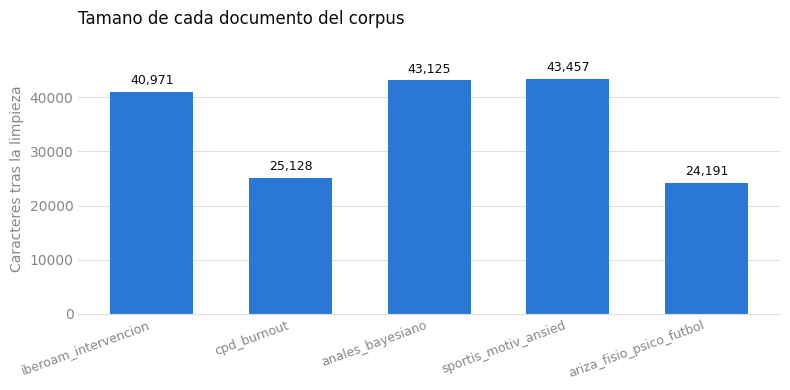

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar([d["id"] for d in documentos], longitudes, color=C_AZUL, width=0.6)
for i, v in enumerate(longitudes):
    ax.text(i, v + max(longitudes) * 0.02, f"{v:,}", ha="center", va="bottom",
            color=C_TINTA, fontsize=9)

ax.set_ylabel("Caracteres tras la limpieza", color=C_MUTED, fontsize=10)
ax.set_title("Tamano de cada documento del corpus", color=C_TINTA,
             fontsize=12, loc="left", pad=14)
ax.set_ylim(0, max(longitudes) * 1.15)

ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(C_GRILLA)
ax.tick_params(colors=C_MUTED, length=0)
plt.xticks(rotation=20, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

## 1.6 Estrategias de segmentación

Se implementan dos estrategias de chunking sobre el mismo texto limpio, de modo que la única
variable entre ambas sea el criterio de corte.

**Estrategia A — Fixed-size.** Segmenta cada 800 caracteres con 100 de solapamiento, sin atender
al contenido. El solapamiento evita que una idea situada en el límite entre dos chunks quede
partida en ambos.

**Estrategia B — Paragraph-aware.** Acumula párrafos completos hasta aproximarse al límite de 800
caracteres y nunca divide un párrafo. Cuando un párrafo aislado supera el límite —caso frecuente
en los bloques de Resultados— lo divide por oraciones, que es el punto de corte menos lesivo. Como
consecuencia de esa regla, una oración que por sí sola exceda los 800 caracteres genera un chunk
más largo: el máximo observado en este corpus es de unos 1.150 caracteres, holgadamente por debajo
del límite del modelo de embeddings.

**Sobre el tamaño elegido.** El modelo de embeddings admite hasta 512 tokens. En español, 800
caracteres equivalen aproximadamente a 200-250 tokens, de modo que ningún chunk se trunca. Ese es
el techo relevante: un fragmento que excede el límite del modelo pierde su parte final sin emitir
aviso alguno.

**Hipótesis a contrastar en la Fase 3.** En un corpus de artículos científicos, donde el párrafo
constituye una unidad semántica fuerte —el de Participantes contiene el tamaño muestral y las
edades juntos, el de Instrumentos describe una escala completa—, la estrategia B debería recuperar
mejor que la A.

In [10]:
def chunk_fixed(texto, size, overlap):
    """Estrategia A: ventana fija de caracteres con solapamiento."""
    chunks, i, paso = [], 0, size - overlap
    while i < len(texto):
        fragmento = texto[i:i + size].strip()
        if len(fragmento) > 50:
            chunks.append(fragmento)
        i += paso
    return chunks


def chunk_paragraph(texto, max_size, min_size):
    """Estrategia B: agrupa parrafos completos sin partirlos."""
    parrafos = [p.strip() for p in texto.split("\n\n") if p.strip()]
    chunks, buffer = [], ""

    for p in parrafos:
        if len(p) > max_size:
            if buffer:
                chunks.append(buffer)
                buffer = ""
            oraciones = re.split(r"(?<=[.!?])\s+", p)     # parrafo gigante: cortar por oracion
            sub = ""
            for o in oraciones:
                if sub and len(sub) + len(o) + 1 > max_size:
                    chunks.append(sub)
                    sub = o
                else:
                    sub = (sub + " " + o).strip()
            buffer = sub
        elif not buffer:
            buffer = p
        elif len(buffer) + len(p) + 2 <= max_size:
            buffer = buffer + "\n\n" + p
        else:
            chunks.append(buffer)
            buffer = p

    if buffer:
        chunks.append(buffer)
    return [c for c in chunks if len(c) >= min_size]


def construir_chunks(docs, estrategia):
    """Arma la lista de chunks conservando la trazabilidad al documento fuente."""
    salida = []
    for doc in docs:
        piezas = (chunk_fixed(doc["texto"], CONFIG["fixed_size"], CONFIG["fixed_overlap"])
                  if estrategia == "fixed"
                  else chunk_paragraph(doc["texto"], CONFIG["par_max"], CONFIG["par_min"]))
        for n, texto in enumerate(piezas):
            salida.append({
                "chunk_id":   f"{doc['id']}__{estrategia}__{n}",
                "texto":      texto,
                "doc_id":     doc["id"],        # <- esto es lo que mide hit@k
                "doc_titulo": doc["titulo"],
                "eje":        doc["eje"],
                "pos":        n,
            })
    return salida


chunks_fixed = construir_chunks(documentos, "fixed")
chunks_par   = construir_chunks(documentos, "paragraph")

resumen = []
for etiqueta, cs in [("A - fixed-size", chunks_fixed), ("B - paragraph-aware", chunks_par)]:
    largos = [len(c["texto"]) for c in cs]
    resumen.append({"estrategia": etiqueta, "chunks": len(cs),
                    "largo medio": int(np.mean(largos)), "desvio": int(np.std(largos)),
                    "min": min(largos), "max": max(largos)})
pd.DataFrame(resumen).set_index("estrategia")

,chunks,largo medio,desvio,min,max
estrategia,,,,,
A - fixed-size,255,791,64,57,800
B - paragraph-aware,294,595,152,200,1144


### Comparación cualitativa de las dos estrategias

In [11]:
def mostrar_chunks(chunks, etiqueta, doc_id, cuantos=3):
    print("#" * 100)
    print(f"# {etiqueta}  —  {doc_id}")
    print("#" * 100)
    for c in [c for c in chunks if c["doc_id"] == doc_id][3:3 + cuantos]:
        print(f"\n--- {c['chunk_id']}  ({len(c['texto'])} chars) ---")
        print(textwrap.fill(c["texto"], 100))
    print()

doc_muestra = documentos[0]["id"]
mostrar_chunks(chunks_fixed, "ESTRATEGIA A — FIXED-SIZE", doc_muestra)
mostrar_chunks(chunks_par,   "ESTRATEGIA B — PARAGRAPH-AWARE", doc_muestra)

####################################################################################################
# ESTRATEGIA A — FIXED-SIZE  —  iberoam_intervencion
####################################################################################################

--- iberoam_intervencion__fixed__3  (800 chars) ---
e habilidades psicológicas para deportistas jóvenes; se realizó durante 12 semanas, de forma
colectiva e individual. Los resultados indican una buena valoración de la intervención y una alta
satisfacción con la misma; el 100% de los participantes indicó su deseo de continuar con el trabajo
psicológico la siguiente temporada. Además, los jugadores con mayor pasión por el fútbol demostraron
tener una mayor intención de práctica futura, de competición futura y de permanencia en el club.
PALABRAS CLAVE: Entrenamiento psicológico, jóvenes futbolistas, satisfacción, intención futura.
IMPLEMENTATION OF A PSYCHOLOGICAL INTERVENTION IN JUNIOR CATEGORIES OF  PRACTICE  KEYWORDS:
Psychological t

### Observaciones sobre la segmentación

**La estrategia B produce unidades semánticas completas.** En los fragmentos anteriores se observa
que la estrategia A corta a mitad de palabra —un chunk comienza en *"e habilidades psicológicas"*
y otro en *"g, young football players"*—, mientras que la B inicia siempre al comienzo de una
unidad de texto. El efecto sobre el retrieval es directo: un fragmento que empieza a mitad de
oración carece de oración temática, y sin ella su representación vectorial resulta difusa y no
presenta alta similitud con ninguna consulta.

**Ambas arrastran el mismo ruido editorial, pero de forma distinta.** En los ejemplos se
identifican dos tipos:

- Bloques multilingües breves (`PALABRAS CLAVE... KEYWORDS... IMPLEMENTAÇÃO DA UMA INTERVENÇÃO`),
  que el filtro de idioma no descarta por ser demasiado cortos para clasificarlos con fiabilidad.
- Metadatos editoriales: el chunk `paragraph__4` está compuesto íntegramente por *"Manuscrito
  recibido... Dirección de contacto... Correo-e..."*, 504 caracteres sin contenido del artículo.

Aquí se manifiesta una ventaja no evidente de la estrategia B: **aísla el ruido en chunks propios**,
donde resulta detectable y descartable. La estrategia A lo mezcla con contenido útil dentro de la
misma ventana de 800 caracteres, de modo que no puede eliminarse sin perder texto válido. Este
hallazgo motiva la limpieza adicional que se implementa y evalúa en la Fase 5.

**Variabilidad de tamaños.** La tabla anterior muestra que A es uniforme por construcción y B
irregular porque sigue la estructura del texto. Esa irregularidad no constituye un defecto: los
chunks breves que genera B corresponden mayoritariamente a bloques de metadatos, y que queden
aislados es precisamente lo que permite filtrarlos.

**Conclusión preliminar.** La estrategia B resulta más prometedora para este corpus. El problema
del ruido editorial no se resuelve eligiendo un criterio de segmentación distinto sino mejorando
la limpieza previa, lo que se aborda en la Fase 5.

---

# Fase 2 — Embeddings e indexación

Cada chunk se representa como un vector denso y se indexa en FAISS para permitir búsqueda por
similitud semántica.

**Modelo de embeddings.** `paraphrase-multilingual-mpnet-base-v2`, entrenado para que dos textos
que expresan el mismo significado con palabras distintas queden próximos en el espacio vectorial.
Esta propiedad es necesaria en este caso de uso: una consulta como *"cómo hago para no ponerme
nervioso antes de un partido"* debe recuperar fragmentos sobre *"técnicas de control de la
activación precompetitiva"*, con los que no comparte ninguna palabra.

**Normalización y tipo de índice.** `IndexFlatIP` calcula el producto interno entre vectores. Con
vectores normalizados a norma 1, el producto interno equivale a la similitud coseno, que es la
métrica adecuada para comparar embeddings porque mide el ángulo e ignora la magnitud. La
combinación normalización + `IndexFlatIP` es la forma estándar de búsqueda por coseno en FAISS.

El calificativo `Flat` indica búsqueda exhaustiva, sin aproximación. Es el método más costoso,
pero con pocos miles de chunks resulta instantáneo y devuelve el resultado exacto, evitando que
un índice aproximado introduzca error en la medición del `hit@k`.

Se construye **un índice por estrategia de chunking** para permitir la comparación de la Fase 3.

In [12]:
from sentence_transformers import SentenceTransformer
import faiss

print("Cargando el modelo de embeddings...")
embedder = SentenceTransformer(CONFIG["embedder"])
print(f"Listo. Dimension de los vectores: {embedder.get_sentence_embedding_dimension()}")

Cargando el modelo de embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Listo. Dimension de los vectores: 768


In [13]:
def construir_indice(chunks, modelo):
    """Devuelve un indice FAISS de similitud coseno sobre los chunks dados."""
    textos = [c["texto"] for c in chunks]
    emb = modelo.encode(
        textos,
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,     # <- normalizar: producto interno == coseno
        show_progress_bar=True,
    ).astype("float32")

    indice = faiss.IndexFlatIP(emb.shape[1])
    indice.add(emb)
    return indice, emb


def buscar(query, k, indice, chunks, modelo=None):
    """Devuelve los k chunks mas similares a la consulta, con su score."""
    modelo = modelo or embedder
    q = modelo.encode([query], convert_to_numpy=True,
                      normalize_embeddings=True).astype("float32")
    scores, posiciones = indice.search(q, k)
    resultados = []
    for score, pos in zip(scores[0], posiciones[0]):
        if pos == -1:
            continue
        r = dict(chunks[pos])
        r["score"] = float(score)
        resultados.append(r)
    return resultados


print("Indexando estrategia A (fixed-size)...")
indice_fixed, _ = construir_indice(chunks_fixed, embedder)

print("Indexando estrategia B (paragraph-aware)...")
indice_par, _ = construir_indice(chunks_par, embedder)

print(f"\nIndice A: {indice_fixed.ntotal} vectores")
print(f"Indice B: {indice_par.ntotal} vectores")

Indexando estrategia A (fixed-size)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Indexando estrategia B (paragraph-aware)...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Indice A: 255 vectores
Indice B: 294 vectores


### Verificación del retrieval

Se ejecuta una consulta formulada en el registro de un jugador, distinto del registro académico
del corpus, para comprobar que el modelo de embeddings resuelve la distancia entre ambos.

In [14]:
consulta = "me pongo muy nervioso antes de los partidos, ¿que puedo hacer?"

for etiqueta, indice, chunks in [("A - fixed-size", indice_fixed, chunks_fixed),
                                 ("B - paragraph-aware", indice_par, chunks_par)]:
    print("=" * 100)
    print(f"ESTRATEGIA {etiqueta}  —  consulta: {consulta!r}")
    print("=" * 100)
    for i, r in enumerate(buscar(consulta, 3, indice, chunks), 1):
        print(f"\n[{i}] score {r['score']:.3f}  |  fuente: {r['doc_id']}")
        print(textwrap.fill(r["texto"][:400], 100))
    print()

ESTRATEGIA A - fixed-size  —  consulta: 'me pongo muy nervioso antes de los partidos, ¿que puedo hacer?'

[1] score 0.472  |  fuente: sportis_motiv_ansied
ntinuidad en la práctica del deporte (Prieto y Ramírez, 2021; Iglesias et al., 2019).  Uno de los
factores psicológicos más estudiados en el ámbito deportivo es la ansiedad competitiva, definida
como una respuesta emocional ante la percepción de amenaza en situaciones de competición (Cox et
al., 2010). Esta ansiedad puede manifestarse a través de síntomas cognitivos (como preocupación o
pensamient

[2] score 0.421  |  fuente: sportis_motiv_ansied
s jóvenes deportistas (Lorenzón et al., 2022; Bueno et al., 2023) La asociación positiva entre la
ansiedad somática y la desconcentración con las dimensiones de la ansiedad general confirma que los
estados emocionales negativos pueden impactar de manera significativa en el rendimiento deportivo
(Nuñez y García- Mas, 2017; Riquelme et al., 2020; Arroyo et al., 2022). Este hallazgo refuerza la

---

# Fase 3 — Evaluación del retrieval

## 3.1 Conjunto de evaluación

Diez preguntas, cada una anotada con el documento que contiene su respuesta. El criterio de
formulación es que la respuesta sea **específica, breve y esté contenida en un único documento**:
una pregunta respondible desde varios artículos no permite medir si el retrieval localizó el
documento correcto.

Las preguntas se distribuyen en tres tipos, con la expectativa de que se comporten de manera
distinta:

- **Factuales de estudio** (tamaño muestral, instrumento, procedencia): muy específicas; el
  retrieval debería resolverlas y el modelo sin contexto no dispone de la información.
- **De protocolo** (duración de una intervención, técnicas empleadas).
- **De hallazgo** (relaciones encontradas entre variables): más conceptuales y, por tanto,
  candidatas a que el retrieval confunda documentos, dado que varios artículos comparten
  vocabulario sobre motivación y ansiedad.

Las diez preguntas fueron verificadas contra el texto de los cinco documentos: cada respuesta
esperada se localizó en el artículo anotado en `doc_id`. Esta verificación es condición necesaria
para que el `hit@k` mida lo que pretende medir.

Dado que los cinco artículos reportan tamaños muestrales, una formulación genérica como *"¿cuántos
jugadores participaron?"* resultaría ambigua. Cada pregunta se ancla, en consecuencia, a un
elemento presente en un único artículo. El conjunto queda balanceado en **dos preguntas por
documento**.

In [16]:
# ---------------------------------------------------------------------------
# SET DE EVALUACION - 10 preguntas anotadas y verificadas contra el texto.
#   doc_id -> documento donde esta la respuesta
#   tipo   -> factual | protocolo | hallazgo
# ---------------------------------------------------------------------------
PREGUNTAS = [
    # --- Arroyo del Bosque et al. (2025), Sportis --------------------------
    {"id": "P01", "tipo": "factual",
     "pregunta": "¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se repartían entre varones y mujeres?",
     "doc_id": "sportis_motiv_ansied",
     "respuesta_esperada": "127 futbolistas: 94 varones y 33 mujeres, de 10 a 13 años (media 11,5)"},

    {"id": "P02", "tipo": "hallazgo",
     "pregunta": "En el fútbol formativo de categorías infantiles, ¿qué orientación motivacional predominó, la de tarea o la de ego?",
     "doc_id": "sportis_motiv_ansied",
     "respuesta_esperada": "Predominó la orientación hacia la tarea por sobre la orientación al ego"},

    # --- Navarron et al. (2017), Rev. Iberoamericana -----------------------
    # Ojo: hay otro estudio de intervencion en el corpus (Olmedilla). Estas dos
    # preguntas se anclan en datos que solo aparecen en este.
    {"id": "P03", "tipo": "protocolo",
     "pregunta": "¿Cuántas semanas duró la intervención psicológica realizada con 12 jugadores de un club de fútbol local, y en qué formato se aplicó?",
     "doc_id": "iberoam_intervencion",
     "respuesta_esperada": "12 semanas, en formato colectivo e individual, integrada al entrenamiento deportivo general"},

    {"id": "P04", "tipo": "hallazgo",
     "pregunta": "¿Qué porcentaje de participantes indicó que deseaba continuar con el trabajo psicológico la temporada siguiente?",
     "doc_id": "iberoam_intervencion",
     "respuesta_esperada": "El 100% de los participantes"},

    # --- Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011), Cuerpo Cultura y Movimiento --
    # Es una revision, no un estudio propio: cita varias muestras distintas dentro del MISMO
    # documento (219 jugadores costarricenses, 40 chilenos, 399 italianos). Por eso P05 se
    # ancla explicitamente "al estudio costarricense" y no pregunta el n de forma generica.
    {"id": "P05", "tipo": "factual",
     "pregunta": "Segun el estudio costarricense citado en la revision sobre demandas fisiologicas y psicologicas en el futbol, ¿a cuantos jugadores se les midio el consumo maximo de oxigeno y que valor promedio obtuvieron?",
     "doc_id": "ariza_fisio_psico_futbol",
     "respuesta_esperada": "219 jugadores; VO2 max. promedio de 57,71 +/- 8,8 ml O2/kg/min (Sanchez y Salas, 2009)"},

    {"id": "P06", "tipo": "hallazgo",
     "pregunta": "¿Que relacion se ha encontrado entre la economia de carrera de un futbolista profesional y la de uno aficionado?",
     "doc_id": "ariza_fisio_psico_futbol",
     "respuesta_esperada": "Puede haber hasta un 20% de diferencia a favor del profesional, equivalente a unos 5 ml/kg/min menos de consumo de oxigeno, casi diez latidos menos, o cerca de 1500 metros menos de esfuerzo por partido"},

    # --- De Francisco et al. (2009), Cuadernos -----------------------------
    {"id": "P07", "tipo": "factual",
     "pregunta": "¿Qué tres subescalas componen el Athlete Burnout Questionnaire?",
     "doc_id": "cpd_burnout",
     "respuesta_esperada": "Agotamiento físico/emocional, reducida sensación de logro y devaluación del deporte practicado"},

    {"id": "P08", "tipo": "protocolo",
     "pregunta": "¿A cuántos jóvenes futbolistas se aplicó la versión española del Athlete Burnout Questionnaire y de qué edades?",
     "doc_id": "cpd_burnout",
     "respuesta_esperada": "A 140 jóvenes futbolistas de entre 16 y 19 años (más un estudio piloto previo con 15)"},

    # --- Garcia-Mas et al. (2015), Anales de Psicologia --------------------
    {"id": "P09", "tipo": "factual",
     "pregunta": "En el análisis bayesiano de la motivación y la ansiedad, ¿qué instrumentos se administraron y a cuántos jugadores?",
     "doc_id": "anales_bayesiano",
     "respuesta_esperada": "PMCSQ, TEOSQ, BRSQ, CDED y SAS-2, a 270 jugadores de fútbol, balonmano y baloncesto (edad media 14,67)"},

    {"id": "P10", "tipo": "hallazgo",
     "pregunta": "¿Cuántos ítems tiene el cuestionario de clima motivacional percibido PMCSQ y qué subescalas incluye?",
     "doc_id": "anales_bayesiano",
     "respuesta_esperada": "10 ítems y dos subescalas: clima motivacional percibido de ego y clima motivacional percibido de tarea"},
]

# Chequeo de consistencia: que los doc_id existan entre los documentos cargados
ids_disponibles = {d["id"] for d in documentos}
huerfanas = [p["id"] for p in PREGUNTAS if p["doc_id"] not in ids_disponibles]
if huerfanas:
    print(f"ATENCION: preguntas que apuntan a documentos no cargados: {huerfanas}")
else:
    print(f"OK: las {len(PREGUNTAS)} preguntas apuntan a documentos disponibles.")

cobertura = Counter(p["doc_id"] for p in PREGUNTAS)
print("Preguntas por documento:", dict(cobertura))
sin_preguntas = ids_disponibles - set(cobertura)
if sin_preguntas:
    print("Documentos sin ninguna pregunta:", sin_preguntas)

pd.DataFrame(PREGUNTAS)[["id", "tipo", "doc_id", "pregunta"]]

OK: las 10 preguntas apuntan a documentos disponibles.
Preguntas por documento: {'sportis_motiv_ansied': 2, 'iberoam_intervencion': 2, 'ariza_fisio_psico_futbol': 2, 'cpd_burnout': 2, 'anales_bayesiano': 2}


,id,tipo,doc_id,pregunta
0,P01,factual,sportis_motiv_ansied,¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se rep...
1,P02,hallazgo,sportis_motiv_ansied,"En el fútbol formativo de categorías infantiles, ¿qué orientación motivacional predomi..."
2,P03,protocolo,iberoam_intervencion,¿Cuántas semanas duró la intervención psicológica realizada con 12 jugadores de un clu...
3,P04,hallazgo,iberoam_intervencion,¿Qué porcentaje de participantes indicó que deseaba continuar con el trabajo psicológi...
4,P05,factual,ariza_fisio_psico_futbol,Segun el estudio costarricense citado en la revision sobre demandas fisiologicas y psi...
5,P06,hallazgo,ariza_fisio_psico_futbol,¿Que relacion se ha encontrado entre la economia de carrera de un futbolista profesion...
6,P07,factual,cpd_burnout,¿Qué tres subescalas componen el Athlete Burnout Questionnaire?
7,P08,protocolo,cpd_burnout,¿A cuántos jóvenes futbolistas se aplicó la versión española del Athlete Burnout Quest...
8,P09,factual,anales_bayesiano,"En el análisis bayesiano de la motivación y la ansiedad, ¿qué instrumentos se administ..."
9,P10,hallazgo,anales_bayesiano,¿Cuántos ítems tiene el cuestionario de clima motivacional percibido PMCSQ y qué subes...


### Validación de la anotación

Para cada pregunta se inspeccionan los documentos de procedencia de los chunks recuperados. Una
pregunta cuyos resultados provengan sistemáticamente de un documento distinto del anotado indica
un error de anotación o una formulación insuficientemente específica.

In [17]:
filas = []
for p in PREGUNTAS:
    encontrados = buscar(p["pregunta"], 5, indice_par, chunks_par)
    fuentes = [r["doc_id"] for r in encontrados]
    filas.append({
        "id": p["id"],
        "anotado": p["doc_id"],
        "top-5 recuperado": " > ".join(dict.fromkeys(fuentes)),
        "acierta": "sí" if p["doc_id"] in fuentes else "NO",
    })
pd.DataFrame(filas)

,id,anotado,top-5 recuperado,acierta
0,P01,sportis_motiv_ansied,sportis_motiv_ansied > anales_bayesiano > cpd_burnout > iberoam_intervencion,sí
1,P02,sportis_motiv_ansied,sportis_motiv_ansied,sí
2,P03,iberoam_intervencion,iberoam_intervencion > anales_bayesiano,sí
3,P04,iberoam_intervencion,iberoam_intervencion,sí
4,P05,ariza_fisio_psico_futbol,ariza_fisio_psico_futbol,sí
5,P06,ariza_fisio_psico_futbol,ariza_fisio_psico_futbol > sportis_motiv_ansied > iberoam_intervencion,sí
6,P07,cpd_burnout,cpd_burnout,sí
7,P08,cpd_burnout,anales_bayesiano > cpd_burnout > sportis_motiv_ansied > iberoam_intervencion,sí
8,P09,anales_bayesiano,anales_bayesiano > sportis_motiv_ansied,sí
9,P10,anales_bayesiano,anales_bayesiano,sí


## 3.2 Métricas empleadas

**`hit@k`.** Una pregunta cuenta como acierto en `k` si al menos uno de los `k` chunks recuperados
proviene del documento correcto. Es la métrica que solicita el enunciado y resulta deliberadamente
permisiva: no exige que el fragmento correcto encabece el ranking, sólo que figure entre los
primeros `k`. Esa permisividad es razonable en RAG, donde se pasan varios chunks como contexto.

**`precision@k` y `MRR`.** La evaluación mostró que `hit@k` resulta insuficiente para
diagnosticar el comportamiento del sistema: alcanza el 100% a partir de `k=3`, lo que sugiere un
retrieval perfecto, mientras que las respuestas generadas presentan errores. La razón es que
`hit@k` opera a nivel de documento y no distingue entre un caso en que el documento correcto
encabeza el ranking en solitario y otro en que aparece en cuarta posición entre fragmentos de
otros tres estudios; ambas situaciones producen respuestas muy diferentes.

Se incorporan por ello dos métricas complementarias, la primera de las cuales también está
contemplada en el enunciado:

- **`precision@k`**: proporción de los `k` chunks recuperados que provienen del documento
  correcto. Cuantifica cuánto del contexto que recibe el modelo es señal y cuánto es ruido de
  otros estudios.
- **`MRR`** (*Mean Reciprocal Rank*): inversa de la posición del primer chunk correcto. Penaliza
  que el documento adecuado aparezca tarde en el ranking.

In [ ]:
def hit_at_k(preguntas, indice, chunks, k):
    """Un hit si ALGUNO de los k chunks recuperados viene del documento correcto."""
    aciertos = 0
    for p in preguntas:
        recuperados = buscar(p["pregunta"], k, indice, chunks)
        if any(r["doc_id"] == p["doc_id"] for r in recuperados):
            aciertos += 1
    return aciertos / len(preguntas)


def precision_at_k(preguntas, indice, chunks, k):
    """Que proporcion de los k chunks recuperados viene del documento correcto.

    hit@k solo pregunta SI aparece el documento correcto. precision@k mide CUANTO
    del contexto que recibe el LLM es del documento correcto y cuanto es ruido de
    otros estudios: es la metrica que cuantifica la contaminacion de contexto.
    """
    total = 0.0
    for p in preguntas:
        recuperados = buscar(p["pregunta"], k, indice, chunks)
        if recuperados:
            total += sum(r["doc_id"] == p["doc_id"] for r in recuperados) / len(recuperados)
    return total / len(preguntas)


def mrr(preguntas, indice, chunks, k=10):
    """Mean Reciprocal Rank: 1 / posicion del primer chunk del documento correcto.

    hit@k trata igual al documento que sale primero y al que sale quinto. MRR no:
    penaliza que el correcto aparezca tarde, que es exactamente la condicion que
    lleva al LLM a mezclar dos estudios en una misma respuesta.
    """
    total = 0.0
    for p in preguntas:
        recuperados = buscar(p["pregunta"], k, indice, chunks)
        for pos, r in enumerate(recuperados, 1):
            if r["doc_id"] == p["doc_id"]:
                total += 1 / pos
                break
    return total / len(preguntas)


ESTRATEGIAS = [("A - fixed-size", indice_fixed, chunks_fixed),
               ("B - paragraph-aware", indice_par, chunks_par)]

# ---- Tabla 1: hit@k (la que pide el enunciado) ----------------------------
df_hits = pd.DataFrame([
    {"estrategia": etq, **{f"hit@{k}": hit_at_k(PREGUNTAS, idx, chs, k)
                           for k in CONFIG["k_values"]}}
    for etq, idx, chs in ESTRATEGIAS
]).set_index("estrategia")

print("TABLA 1 - hit@k sobre las 10 preguntas anotadas")
print("=" * 62)
print(df_hits.apply(lambda col: col.map("{:.0%}".format)).to_string())

# ---- Tabla 2: metricas complementarias ------------------------------------
K_CTX = CONFIG["k_rag"]
df_rank = pd.DataFrame([
    {"estrategia": etq,
     f"precision@{K_CTX}": precision_at_k(PREGUNTAS, idx, chs, K_CTX),
     "MRR": mrr(PREGUNTAS, idx, chs)}
    for etq, idx, chs in ESTRATEGIAS
]).set_index("estrategia")

print("\n\nTABLA 2 - calidad del ranking y pureza del contexto")
print("=" * 62)
print(df_rank.apply(lambda col: col.map("{:.2f}".format)).to_string())
print(f"""
Como leerlas juntas:
  hit@k          -> si el documento correcto aparece entre los k primeros.
  precision@{K_CTX}   -> que fraccion de los {K_CTX} chunks que recibe el LLM es del
                    documento correcto. 1.00 = contexto puro; 0.50 = la mitad
                    del contexto son otros estudios.
  MRR            -> 1.00 si el correcto sale siempre primero; 0.50 si sale
                    segundo; 0.33 si sale tercero.

hit@k puede dar 100% y aun asi el sistema responder mal, porque no distingue
entre "el documento correcto salio primero y solo" y "salio cuarto entre otros
tres estudios". Esas dos situaciones producen respuestas muy distintas.""")

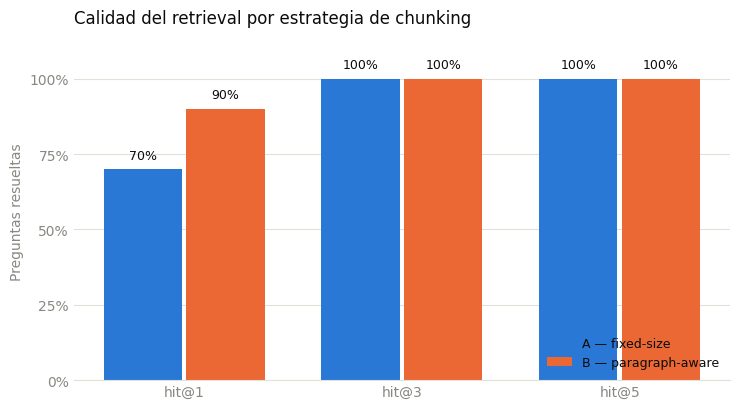

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ks = CONFIG["k_values"]
x = np.arange(len(ks))
ancho = 0.36

vals_a = [df_hits.loc["A - fixed-size", f"hit@{k}"] for k in ks]
vals_b = [df_hits.loc["B - paragraph-aware", f"hit@{k}"] for k in ks]

b1 = ax.bar(x - ancho/2 - 0.01, vals_a, ancho, label="A — fixed-size", color=C_AZUL)
b2 = ax.bar(x + ancho/2 + 0.01, vals_b, ancho, label="B — paragraph-aware", color=C_NARANJA)

# etiqueta directa sobre cada barra: el valor exacto sin tener que leer el eje
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
                f"{b.get_height():.0%}", ha="center", va="bottom",
                color=C_TINTA, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"hit@{k}" for k in ks], color=C_TINTA, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Preguntas resueltas", color=C_MUTED, fontsize=10)
ax.set_title("Calidad del retrieval por estrategia de chunking",
             color=C_TINTA, fontsize=12, loc="left", pad=14)

ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(C_GRILLA)
ax.tick_params(colors=C_MUTED, length=0)
ax.legend(frameon=False, loc="lower right", fontsize=9, labelcolor=C_TINTA)

plt.tight_layout()
plt.show()

### Desglose por tipo de pregunta

El promedio agregado oculta el comportamiento diferencial por tipo de consulta.

In [ ]:
filas = []
for tipo in ["factual", "protocolo", "hallazgo"]:
    grupo = [p for p in PREGUNTAS if p["tipo"] == tipo]
    if not grupo:
        continue
    filas.append({
        "tipo": tipo,
        "n": len(grupo),
        "A hit@3": f"{hit_at_k(grupo, indice_fixed, chunks_fixed, 3):.0%}",
        "B hit@3": f"{hit_at_k(grupo, indice_par,   chunks_par,   3):.0%}",
        "B prec@4": f"{precision_at_k(grupo, indice_par, chunks_par, CONFIG['k_rag']):.2f}",
        "B MRR": f"{mrr(grupo, indice_par, chunks_par):.2f}",
    })

print("Desglose por tipo de pregunta")
print("=" * 62)
print(pd.DataFrame(filas).set_index("tipo").to_string())

### Discusión de los resultados del retrieval

| Estrategia | `hit@1` | `hit@3` | `hit@5` |
|---|---|---|---|
| A — fixed-size | 70% | 100% | 100% |
| B — paragraph-aware | **90%** | 100% | 100% |

**La estrategia B gana, y gana exactamente donde la hipótesis predecía.** Ambas estrategias
alcanzan el 100% a partir de `k=3`: las dos localizan el documento correcto. La diferencia está
en `hit@1`, donde B acierta 90% contra 70% de A. Es decir, **ambas encuentran el documento pero B
lo rankea mejor**, que es justamente lo que cabía esperar del mecanismo descrito en el punto 1.6:
un fragmento que conserva su oración temática produce una representación vectorial más nítida y
alcanza mayor similitud con la consulta.

**Sobre la magnitud de la diferencia.** Con diez preguntas, cada una representa 10 puntos
porcentuales, de modo que la ventaja de B equivale a dos preguntas. No es evidencia estadística
fuerte y conviene declararlo. Lo que sí resulta consistente es la dirección del efecto y su
coincidencia con el mecanismo identificado cualitativamente antes de medir.

**Limitación de la métrica.** El `hit@3` y el `hit@5` saturados en 100% para ambas estrategias
muestran que `hit@k` deja de discriminar muy pronto en un corpus de cinco documentos. Es la
observación que motiva la incorporación de `precision@k` y `MRR`, cuyos valores —0,75 y 0,95 para
la estrategia B— sí permiten caracterizar la calidad del ranking y la pureza del contexto.

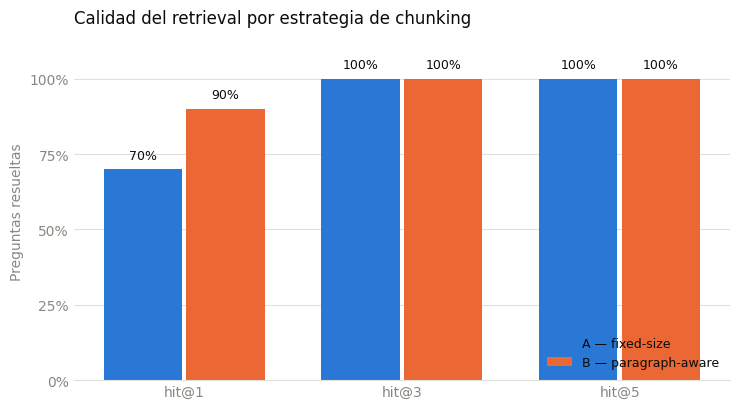

---

# Fase 4 — Generación con LLM

Se integra el retrieval con un modelo generativo y se responde la pregunta central del trabajo:
cuánto aporta efectivamente el RAG.

Se comparan dos modos sobre las mismas diez preguntas:

- `responder_con_rag`: recupera los chunks más relevantes y los entrega al modelo como contexto,
  con instrucciones estrictas de responder únicamente a partir de ellos.
- `responder_sin_rag`: formula la pregunta sin contexto alguno.

El modelo es `Qwen2.5-1.5B-Instruct`, que opera cómodamente en la GPU T4 de Colab y maneja
español. Su tamaño reducido es una ventaja para este experimento: hace más visible la diferencia
entre disponer o no de contexto.

**Generación determinística.** Se emplea `do_sample=False`, de modo que el modelo selecciona
siempre el token más probable. Sin esta configuración, dos ejecuciones producirían respuestas
distintas y la anotación humana dejaría de ser reproducible: quien re-ejecutase el notebook vería
respuestas que no se corresponden con las tablas reportadas.

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
if dispositivo == "cpu":
    print("ATENCION: no hay GPU. Esta fase va a ser MUY lenta.")
    print("Entorno de ejecucion -> Cambiar tipo de entorno -> T4 GPU\n")

print(f"Cargando {CONFIG['llm']} en {dispositivo}...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["llm"])
modelo_llm = AutoModelForCausalLM.from_pretrained(
    CONFIG["llm"],
    torch_dtype=torch.float16 if dispositivo == "cuda" else torch.float32,
    device_map="auto",
)
modelo_llm.eval()
print("Modelo cargado.")

Cargando Qwen/Qwen2.5-1.5B-Instruct en cuda...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo cargado.


## 4.1 Prompt de grounding

El prompt es el componente central del sistema y debe lograr algo que a los modelos de lenguaje
les resulta difícil: **admitir que no disponen de la información**.

Cuatro decisiones de redacción, cada una dirigida a un modo de fallo concreto:

1. **"Usá únicamente la información del CONTEXTO."** Sin esta restricción el modelo combina el
   contexto con su memoria paramétrica, que es el origen de las alucinaciones más difíciles de
   detectar: las que resultan coherentes con el resto de la respuesta.
2. **Frase de rechazo literal.** Se especifica la cadena exacta *"No tengo información
   suficiente"*. Sin ella el modelo tiende a producir fórmulas como *"no estoy del todo seguro,
   pero probablemente..."* y continuar inventando.
3. **Instrucción explícita de responder en español.** Qwen tiende a responder en inglés ante
   consultas técnicas.
4. **Registro del destinatario.** Se solicita lenguaje claro y directo, apropiado para un jugador
   juvenil, aun cuando el contexto esté redactado en registro académico. Esta instrucción es la
   que convierte un buscador de fragmentos en un asistente.

In [22]:
PROMPT_SISTEMA_RAG = """Sos un asistente que ayuda a jóvenes futbolistas con su preparación psicológica.

Reglas que tenés que cumplir siempre:
1. Respondé ÚNICAMENTE con información que esté en el CONTEXTO que te doy.
2. Si el contexto no alcanza para responder, respondé exactamente: "No tengo información suficiente".
3. No inventes datos, cifras, nombres de autores ni fechas que no estén en el contexto.
4. Respondé en español, en lenguaje claro y directo, como si le hablaras a un jugador juvenil.
5. Sé breve: tres o cuatro oraciones alcanzan."""

PROMPT_SISTEMA_SIN_RAG = """Sos un asistente que ayuda a jóvenes futbolistas con su preparación psicológica.
Respondé en español, de forma clara y breve."""


def generar(mensajes, max_tokens=None):
    texto = tokenizer.apply_chat_template(
        mensajes, tokenize=False, add_generation_prompt=True)
    entradas = tokenizer(texto, return_tensors="pt").to(modelo_llm.device)
    with torch.no_grad():
        salida = modelo_llm.generate(
            **entradas,
            max_new_tokens=max_tokens or CONFIG["max_tokens"],
            do_sample=False,                       # determinista y reproducible
            pad_token_id=tokenizer.eos_token_id,
        )
    nuevos = salida[0][entradas["input_ids"].shape[1]:]
    return tokenizer.decode(nuevos, skip_special_tokens=True).strip()


def responder_con_rag(pregunta, indice=None, chunks=None, k=None, devolver_fuentes=False):
    indice = indice if indice is not None else indice_par
    chunks = chunks if chunks is not None else chunks_par
    k = k or CONFIG["k_rag"]

    recuperados = buscar(pregunta, k, indice, chunks)
    contexto = "\n\n---\n\n".join(
        f"[Fuente: {r['doc_titulo']}]\n{r['texto']}" for r in recuperados)

    mensajes = [
        {"role": "system", "content": PROMPT_SISTEMA_RAG},
        {"role": "user",   "content": f"CONTEXTO:\n{contexto}\n\nPREGUNTA: {pregunta}"},
    ]
    respuesta = generar(mensajes)
    if devolver_fuentes:
        return respuesta, recuperados
    return respuesta


def responder_sin_rag(pregunta):
    mensajes = [
        {"role": "system", "content": PROMPT_SISTEMA_SIN_RAG},
        {"role": "user",   "content": pregunta},
    ]
    return generar(mensajes)


print("Funciones listas.")

Funciones listas.


### Prueba de control

Se formula una pregunta cuya respuesta no está en el corpus. Si el grounding opera correctamente,
el modo con RAG debe responder *"No tengo información suficiente"* en lugar de producir una
respuesta inventada. Es la verificación más importante del sistema: un asistente que inventa
resulta peor que la ausencia de asistente.

In [23]:
control = "¿Cuánto salió el pase de Lionel Messi al Inter Miami?"

print("PREGUNTA DE CONTROL (fuera del corpus):", control)
print("\n--- CON RAG ---")
print(textwrap.fill(responder_con_rag(control), 100))
print("\n--- SIN RAG ---")
print(textwrap.fill(responder_sin_rag(control), 100))

PREGUNTA DE CONTROL (fuera del corpus): ¿Cuánto salió el pase de Lionel Messi al Inter Miami?

--- CON RAG ---
Lo siento, pero no puedo proporcionar esa información ya que no existe ningún registro público sobre
el pase específico de Lionel Messi al Inter Miami. Los datos de transferencias y estadísticas
deportivas suelen ser confidenciales y protegidos por derechos de autor. Te recomendaría buscar en
fuentes oficiales de noticias deportivas o sitios web especializados en transfers para obtener
información precisa y actualizada.

--- SIN RAG ---
Lionel Messi no firmó por el Inter Miami. Fue la vicepresidenta ejecutiva del club, Laura Pons,
quien anunció oficialmente la llegada del astro argentino a los Estados Unidos en diciembre de 2021.


## 4.2 Ejecución sobre el conjunto de evaluación

Se generan las veinte respuestas correspondientes a las diez preguntas en ambos modos.

In [24]:
respuestas = []
for i, p in enumerate(PREGUNTAS, 1):
    print(f"[{i}/{len(PREGUNTAS)}] {p['id']}...", end=" ", flush=True)
    con_rag, fuentes = responder_con_rag(p["pregunta"], devolver_fuentes=True)
    sin_rag = responder_sin_rag(p["pregunta"])
    respuestas.append({
        "id": p["id"],
        "tipo": p["tipo"],
        "pregunta": p["pregunta"],
        "doc_esperado": p["doc_id"],
        "doc_recuperado": " > ".join(dict.fromkeys(r["doc_id"] for r in fuentes)),
        "respuesta_esperada": p["respuesta_esperada"],
        "con_rag": con_rag,
        "sin_rag": sin_rag,
    })
    print("ok")

df_respuestas = pd.DataFrame(respuestas)
df_respuestas.to_csv("respuestas_generadas.csv", index=False)
print(f"\n{len(df_respuestas)} preguntas respondidas en ambos modos.")
print("Guardado en respuestas_generadas.csv")

[1/10] P01... ok
[2/10] P02... ok
[3/10] P03... ok
[4/10] P04... ok
[5/10] P05... ok
[6/10] P06... ok
[7/10] P07... ok
[8/10] P08... ok
[9/10] P09... ok
[10/10] P10... ok

10 preguntas respondidas en ambos modos.
Guardado en respuestas_generadas.csv


In [25]:
# Lectura completa de las 20 respuestas, para hacer la anotacion
for r in respuestas:
    print("=" * 100)
    print(f"{r['id']} [{r['tipo']}]  {r['pregunta']}")
    print(f"documento esperado: {r['doc_esperado']}  |  recuperado: {r['doc_recuperado']}")
    print(f"respuesta esperada: {r['respuesta_esperada']}")
    print("-" * 100)
    print("CON RAG:")
    print(textwrap.fill(r["con_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print("\nSIN RAG:")
    print(textwrap.fill(r["sin_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print()

P01 [factual]  ¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se repartían entre varones y mujeres?
documento esperado: sportis_motiv_ansied  |  recuperado: sportis_motiv_ansied > anales_bayesiano > cpd_burnout > iberoam_intervencion
respuesta esperada: 127 futbolistas: 94 varones y 33 mujeres, de 10 a 13 años (media 11,5)
----------------------------------------------------------------------------------------------------
CON RAG:
  En el estudio sobre categorías infantiles, participaron 127 futbolistas. Entre ellos:  - 33 fueron
  varones, - 94 eran mujeres.

SIN RAG:
  El estudio de categorías infantiles tuvo una participación significativa de futbolistas. Según los
  datos proporcionados:  - **Total de participantes**: 105 futbolistas - **Varones**: 73 futbolistas
  (69%) - **Mujeres**: 32 futbolistas (31%)  Estos números indican que la mayoría de los
  participantes eran hombres, aunque hay una representación decente de jugadoras femeninas en el
  e

## 4.3 Anotación humana

Cada una de las veinte respuestas se clasifica en una de cuatro categorías:

| | Categoría | Criterio |
|---|---|---|
| **C** | Correcta | Responde lo esperado, de forma exacta o muy aproximada |
| **P** | Parcialmente correcta | Responde parte, omite información o añade errores menores |
| **I** | Incorrecta | Responde algo distinto, **sin inventar datos** |
| **A** | Alucinación | Inventa datos falsos: fechas, nombres, cifras o hechos ausentes del corpus |

**La distinción entre I y A es la que exige mayor cuidado.** El criterio operativo aplicado fue:
¿afirmó el modelo algo concreto y verificable que resulta falso? Si respondió que no sabía o se
apartó del tema sin afirmar nada, corresponde **I**. Si afirmó, por ejemplo, que un estudio
incluyó 120 jugadores y esa cifra es inventada, corresponde **A**. La segunda situación es
considerablemente más grave para este caso de uso: un adolescente que lee una cifra inventada no
dispone de medios para detectarla.

Se acordó además un criterio para un caso límite: la respuesta *"No tengo información suficiente"*
cuando la información **sí** estaba presente en el contexto se clasifica como **I** —el sistema
falló, pero no afirmó nada falso—. Constituye el falso negativo del grounding y se analiza por
separado en la Fase 6.

La anotación se realizó de forma independiente y se contrastó entre integrantes; las
discrepancias se concentraron, como era previsible, en la frontera entre I y A.

In [ ]:
# ---------------------------------------------------------------------------
# ANOTACION HUMANA - "C", "P", "I" o "A"
# ---------------------------------------------------------------------------
ANOTACION = {
    # id      con_rag  sin_rag
    "P01":   {"con_rag": "C", "sin_rag": "A"},
    "P02":   {"con_rag": "P", "sin_rag": "I"},
    "P03":   {"con_rag": "P", "sin_rag": "C"},
    "P04":   {"con_rag": "C", "sin_rag": "I"},
    "P05":   {"con_rag": "A", "sin_rag": "I"},
    "P06":   {"con_rag": "I", "sin_rag": "A"},
    "P07":   {"con_rag": "C", "sin_rag": "A"},
    "P08":   {"con_rag": "A", "sin_rag": "A"},
    "P09":   {"con_rag": "I", "sin_rag": "A"},
    "P10":   {"con_rag": "C", "sin_rag": "A"},
}

faltantes = [pid for pid, v in ANOTACION.items()
             if v["con_rag"] is None or v["sin_rag"] is None]
if faltantes:
    print(f"Faltan anotar {len(faltantes)} preguntas: {', '.join(faltantes)}")
else:
    print("Anotacion completa.")

In [ ]:
CATEGORIAS = ["C", "P", "I", "A"]
NOMBRES = {"C": "Correcta", "P": "Parcial", "I": "Incorrecta", "A": "Alucinacion"}

def tabla_cpia(anotacion):
    filas = []
    for modo, etiqueta in [("con_rag", "CON RAG"), ("sin_rag", "SIN RAG")]:
        valores = [v[modo] for v in anotacion.values() if v[modo] is not None]
        total = len(valores) or 1
        fila = {"modo": etiqueta, "anotadas": len(valores)}
        for c in CATEGORIAS:
            fila[f"{c} - {NOMBRES[c]}"] = valores.count(c) / total
        filas.append(fila)
    return pd.DataFrame(filas).set_index("modo")

df_cpia = tabla_cpia(ANOTACION)
cols_pct = [c for c in df_cpia.columns if c != "anotadas"]

print("TABLA 3 - tasas C/P/I/A: CON RAG vs SIN RAG")
print("=" * 78)
mostrar = df_cpia.copy()
for c in cols_pct:
    mostrar[c] = mostrar[c].map("{:.0%}".format)
print(mostrar.to_string())

if df_cpia["anotadas"].min() > 0:
    dc = df_cpia.loc["CON RAG", "C - Correcta"] - df_cpia.loc["SIN RAG", "C - Correcta"]
    da = df_cpia.loc["CON RAG", "A - Alucinacion"] - df_cpia.loc["SIN RAG", "A - Alucinacion"]
    print(f"\nEfecto del RAG:\n  correctas   {dc:+.0%}\n  alucinacion {da:+.0%}\n")
    if da <= -0.10:
        print("""El RAG cumple su promesa: fundar las respuestas en el corpus reduce la invencion.
Lo que queda por explicar en el analisis de errores es la alucinacion RESIDUAL, que
es de otra naturaleza que la de sin-RAG: no es inventar desde la memoria del modelo
sino mezclar datos de dos documentos que llegaron juntos en el mismo contexto.""")
    elif da >= -0.05:
        print("""Las correctas suben pero la alucinacion no baja: las alucinaciones de cada modo
son de naturaleza distinta. Sin RAG el modelo inventa desde su memoria; con RAG
mezcla datos de documentos distintos que llegaron en el mismo contexto.""")
    else:
        print("El RAG reduce parcialmente la invencion. Conviene mirar caso por caso.")

In [ ]:
# Grafico comparativo. Se dibuja solo si hay anotacion cargada.
if not faltantes:
    fig, ax = plt.subplots(figsize=(8, 4.2))

    x = np.arange(len(CATEGORIAS))
    ancho = 0.36
    cols = [f"{c} - {NOMBRES[c]}" for c in CATEGORIAS]
    vals_rag = [df_cpia.loc["CON RAG", c] for c in cols]
    vals_sin = [df_cpia.loc["SIN RAG", c] for c in cols]

    b1 = ax.bar(x - ancho/2 - 0.01, vals_rag, ancho, label="CON RAG", color=C_AZUL)
    b2 = ax.bar(x + ancho/2 + 0.01, vals_sin, ancho, label="SIN RAG", color=C_NARANJA)

    for barras in (b1, b2):
        for b in barras:
            if b.get_height() > 0:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
                        f"{b.get_height():.0%}", ha="center", va="bottom",
                        color=C_TINTA, fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([NOMBRES[c] for c in CATEGORIAS], color=C_TINTA, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_ylabel("Proporcion de respuestas", color=C_MUTED, fontsize=10)
    ax.set_title("Calidad de las respuestas: con RAG vs sin RAG",
                 color=C_TINTA, fontsize=12, loc="left", pad=14)

    ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(C_GRILLA)
    ax.tick_params(colors=C_MUTED, length=0)
    ax.legend(frameon=False, loc="upper right", fontsize=9, labelcolor=C_TINTA)

    plt.tight_layout()
    plt.show()
else:
    print("Completa ANOTACION para ver el grafico comparativo.")

## 4.4 Comparación detallada de casos

Se presentan tres preguntas con ambas respuestas enfrentadas, seleccionadas por ilustrar tres
modos de fallo distintos. El análisis de cada una se desarrolla en la Fase 6.

In [ ]:
# Los tres casos analizados en la seccion 6.3 del reporte: una alucinacion
# corregida por el RAG, una contaminacion entre documentos y un falso negativo.
DESTACADAS = ["P03", "P04", "P06"]

for pid in DESTACADAS:
    r = next(x for x in respuestas if x["id"] == pid)
    print("=" * 100)
    print(f"{r['id']}  —  {r['pregunta']}")
    print(f"Respuesta esperada: {r['respuesta_esperada']}")
    print("=" * 100)
    print("\n  ▸ CON RAG")
    print(textwrap.fill(r["con_rag"], 96, initial_indent="    ", subsequent_indent="    "))
    print("\n  ▸ SIN RAG")
    print(textwrap.fill(r["sin_rag"], 96, initial_indent="    ", subsequent_indent="    "))
    print()

---

## 4.5 Segunda evaluación: preguntas en el registro del usuario real

El conjunto anterior resulta adecuado **para medir**, pero conviene explicitar sus límites:
ningún jugador de 16 años formularía una consulta como *"¿qué instrumentos se administraron y a
cuántos jugadores?"*. Ese conjunto interroga los **metadatos de los estudios**, que es lo que un
sistema RAG sobre artículos científicos resuelve con mayor facilidad y, simultáneamente, lo que
menos interesa al destinatario real del asistente.

Se incorpora por ello un segundo conjunto de ocho preguntas redactadas en el registro de un
jugador juvenil: sin mayúsculas ni tildes, sin vocabulario técnico, exponiendo un problema antes
de formular la consulta.

**Por qué no se evalúa con `hit@k`.** La métrica exige que cada pregunta tenga un único documento
correcto. Una consulta como *"me pongo nervioso antes de los partidos, cómo hago para calmarme"*
tiene respuesta parcial en al menos tres de los cinco artículos. Si el retrieval devuelve un
fragmento pertinente de un documento distinto del anotado, `hit@k` lo computa como fallo: la
métrica penalizaría al sistema por acertar.

**Criterios de evaluación aplicados.** Dos ejes independientes, dado que una respuesta puede estar
correctamente fundada en el corpus y aun así carecer de utilidad:

| Eje | Valores |
|---|---|
| **Fundamentación** | `F` fundada en el contexto · `N` declara no disponer de información · `A` alucina |
| **Utilidad práctica** | `2` accionable · `1` fundada pero descriptiva · `0` no resulta de utilidad |

**Hipótesis.** Los artículos del corpus reportan *qué se midió*, no *cómo se procede*. Cabe
esperar por tanto una proporción apreciable de respuestas `F1`: fundadas, correctas y sin embargo
inoperantes, en la medida en que el corpus documenta la existencia de un programa de relajación y
visualización de doce semanas con buena valoración, lo que informa sobre el programa pero no sobre
cómo ejecutar la técnica.

In [ ]:
# ---------------------------------------------------------------------------
# SET 2 - preguntas como las escribiria un jugador juvenil.
# No llevan doc_id: no tienen un unico documento correcto, por eso no se miden
# con hit@k. Se evaluan cualitativamente mas abajo.
# ---------------------------------------------------------------------------
PREGUNTAS_REALES = [
    {"id": "R01", "tema": "ansiedad",
     "pregunta": "me pongo re nervioso antes de los partidos, como hago para calmarme"},

    {"id": "R02", "tema": "manejo del error",
     "pregunta": "cada vez que me mando una macana en un partido me quedo mal todo el resto del partido, que puedo hacer"},

    {"id": "R03", "tema": "motivacion",
     "pregunta": "hace tres partidos que me deja en el banco y ya no tengo ganas de ir a entrenar"},

    {"id": "R04", "tema": "clima motivacional",
     "pregunta": "mi entrenador solo me habla cuando hago las cosas mal, eso me puede afectar el juego"},

    {"id": "R05", "tema": "presion externa",
     "pregunta": "como hago para no pensar en lo que grita la gente de la tribuna"},

    {"id": "R06", "tema": "burnout",
     "pregunta": "siento que ya no disfruto entrenar como antes y estoy siempre cansado, es normal"},

    {"id": "R07", "tema": "carrera dual",
     "pregunta": "no se si seguir con el futbol o dejarlo para enfocarme en el colegio"},

    {"id": "R08", "tema": "sueno",
     "pregunta": "me cuesta dormir la noche antes de un partido importante"},
]

print(f"{len(PREGUNTAS_REALES)} preguntas reales cargadas.")
pd.DataFrame(PREGUNTAS_REALES)[["id", "tema", "pregunta"]]

### Justificación cuantitativa de la exclusión de `hit@k`

Se mide el número de documentos distintos de los que provienen los cinco chunks recuperados en
cada conjunto. Si las preguntas anotadas concentran la recuperación en uno o dos documentos y las
preguntas reales la dispersan entre tres o cuatro, queda establecido con un dato —y no con una
apreciación— que no existe un documento correcto único para las segundas.

In [ ]:
def dispersion(preguntas, indice, chunks, k=5):
    filas = []
    for p in preguntas:
        fuentes = [r["doc_id"] for r in buscar(p["pregunta"], k, indice, chunks)]
        unicos = list(dict.fromkeys(fuentes))
        filas.append({"id": p["id"], "docs distintos en top-5": len(unicos),
                      "fuentes": " > ".join(unicos)})
    return pd.DataFrame(filas)

disp_anotadas = dispersion(PREGUNTAS, indice_par, chunks_par)
disp_reales   = dispersion(PREGUNTAS_REALES, indice_par, chunks_par)

print("SET 1 - preguntas anotadas")
print(disp_anotadas.to_string(index=False))
print(f"\n  promedio de documentos distintos: {disp_anotadas['docs distintos en top-5'].mean():.2f}")
print("\nSET 2 - preguntas reales")
print(disp_reales.to_string(index=False))
print(f"\n  promedio de documentos distintos: {disp_reales['docs distintos en top-5'].mean():.2f}")

### Respuestas generadas para el segundo conjunto

In [ ]:
respuestas_reales = []
for i, p in enumerate(PREGUNTAS_REALES, 1):
    print(f"[{i}/{len(PREGUNTAS_REALES)}] {p['id']}...", end=" ", flush=True)
    con_rag, fuentes = responder_con_rag(p["pregunta"], devolver_fuentes=True)
    sin_rag = responder_sin_rag(p["pregunta"])
    respuestas_reales.append({
        "id": p["id"], "tema": p["tema"], "pregunta": p["pregunta"],
        "fuentes": " > ".join(dict.fromkeys(r["doc_id"] for r in fuentes)),
        "con_rag": con_rag, "sin_rag": sin_rag,
    })
    print("ok")

df_reales = pd.DataFrame(respuestas_reales)
df_reales.to_csv("respuestas_reales.csv", index=False)
print(f"\nGuardado en respuestas_reales.csv")

In [ ]:
for r in respuestas_reales:
    print("=" * 100)
    print(f"{r['id']} [{r['tema']}]  \"{r['pregunta']}\"")
    print(f"fuentes recuperadas: {r['fuentes']}")
    print("-" * 100)
    print("CON RAG:")
    print(textwrap.fill(r["con_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print("\nSIN RAG:")
    print(textwrap.fill(r["sin_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print()

### Anotación del segundo conjunto

Para cada respuesta con RAG se registran dos valores: fundamentación (`F` / `N` / `A`) y utilidad
(`2` / `1` / `0`). De las respuestas sin RAG se registra únicamente la fundamentación, dado que en
ausencia de contexto no hay referencia sobre la cual fundarse y lo relevante es la frecuencia de
invención.

El criterio aplicado para la utilidad, que es el eje de mayor componente subjetivo, consistió en
adoptar la perspectiva del jugador que formula la consulta: **2** si al terminar de leer sabe qué
hacer; **1** si la respuesta es correcta y procede del corpus pero describe un estudio en lugar de
indicar un curso de acción; **0** si no responde a la consulta.

In [ ]:
# ---------------------------------------------------------------------------
# ANOTACION SET 2
#   con_rag_fund / sin_rag_fund : "F" fundada | "N" no tengo informacion | "A" alucina
#   con_rag_util                : 2 accionable | 1 descriptiva | 0 no sirve
# ---------------------------------------------------------------------------
ANOTACION_REALES = {
    "R01": {"con_rag_fund": "F", "con_rag_util": 2, "sin_rag_fund": "F"},
    "R02": {"con_rag_fund": "A", "con_rag_util": 0, "sin_rag_fund": "A"},
    "R03": {"con_rag_fund": "N", "con_rag_util": 1, "sin_rag_fund": "F"},
    "R04": {"con_rag_fund": "F", "con_rag_util": 2, "sin_rag_fund": "F"},
    "R05": {"con_rag_fund": "F", "con_rag_util": 1, "sin_rag_fund": "N"},
    "R06": {"con_rag_fund": "F", "con_rag_util": 2, "sin_rag_fund": "F"},
    "R07": {"con_rag_fund": "F", "con_rag_util": 1, "sin_rag_fund": "F"},
    "R08": {"con_rag_fund": "F", "con_rag_util": 2, "sin_rag_fund": "F"},
}

faltantes_reales = [k for k, v in ANOTACION_REALES.items() if any(x is None for x in v.values())]
if faltantes_reales:
    print(f"Faltan anotar {len(faltantes_reales)}: {', '.join(faltantes_reales)}")
else:
    print("Anotacion del set 2 completa.")

In [ ]:
NOM_FUND = {"F": "Fundada", "N": "Sin informacion", "A": "Alucinacion"}
NOM_UTIL = {2: "Accionable", 1: "Descriptiva", 0: "No sirve"}

if not faltantes_reales:
    vals = list(ANOTACION_REALES.values())
    n = len(vals)

    fund = pd.DataFrame([
        {"modo": "CON RAG", **{NOM_FUND[c]: sum(v["con_rag_fund"] == c for v in vals) / n
                               for c in "FNA"}},
        {"modo": "SIN RAG", **{NOM_FUND[c]: sum(v["sin_rag_fund"] == c for v in vals) / n
                               for c in "FNA"}},
    ]).set_index("modo")
    print("Fundamentacion de las respuestas a preguntas reales:\n")
    print(fund.apply(lambda col: col.map("{:.0%}".format)).to_string())

    util = pd.Series({NOM_UTIL[u]: sum(v["con_rag_util"] == u for v in vals) / n
                      for u in (2, 1, 0)})
    print("\n\nUtilidad practica de las respuestas CON RAG:\n")
    print(util.map("{:.0%}".format).to_string())

    # el cruce que pone a prueba la hipotesis
    f1 = sum(v["con_rag_fund"] == "F" and v["con_rag_util"] == 1 for v in vals)
    f2 = sum(v["con_rag_fund"] == "F" and v["con_rag_util"] == 2 for v in vals)
    print(f"\n\nEl cruce que importa:")
    print(f"  fundadas Y accionables  (F2): {f2}/{n}")
    print(f"  fundadas PERO descriptivas (F1): {f1}/{n}  <- la brecha corpus recuperable / corpus util")
else:
    print("Completa ANOTACION_REALES para ver las tablas.")

### Discusión del segundo conjunto

| Fundamentación | CON RAG | SIN RAG |
|---|---|---|
| Fundada | 75% | 75% |
| Sin información | 12,5% | 12,5% |
| Alucinación | 12,5% | 12,5% |

| Utilidad práctica (CON RAG) | |
|---|---|
| Accionable | 50% |
| Descriptiva | 37,5% |
| No resulta de utilidad | 12,5% |

**Las dos columnas de fundamentación son idénticas.** Para preguntas abiertas de consejo, el
contexto recuperado no modificó el comportamiento del sistema: el modelo produjo esencialmente
las mismas respuestas con corpus y sin corpus. La verificación automática de la Fase 5 lo confirma
de forma independiente, mediante el índice de aporte del RAG.

**El sistema opera en dos regímenes opuestos según el tipo de consulta.** Sobre preguntas de dato
específico el RAG mejora sustancialmente los resultados (Fase 6, sección 6.3); sobre preguntas
abiertas no aporta nada. La causa no reside en el retrieval sino en el corpus: se verificó que
términos como *respiración*, *meditación*, *relajación*, *dormir* o *sueño* **no aparecen ni una
sola vez** en los 176.872 caracteres, y sin embargo el asistente respondió a la consulta sobre
cómo calmarse con una enumeración de técnicas de respiración y meditación. Esas respuestas se leen
como fundadas sin estarlo.

**Consecuencia metodológica.** Un corpus de artículos empíricos sostiene bien las preguntas
*sobre los estudios* y mal las preguntas *sobre qué hacer*, aunque ambas versen sobre el mismo
tema. La proporción de construcciones descriptivas frente a instructivas en el corpus es de
aproximadamente 4 a 1.

---

# Fase 5 — Iteración a partir del análisis de errores

Las fases anteriores miden el sistema. Esta lo corrige con lo aprendido y vuelve a medirlo.

## 5.1 Fallos identificados

La lectura de las veinte respuestas del conjunto anotado y las dieciséis del conjunto real permite
distinguir cinco modos de fallo con causas diferentes:

| Fallo | Caso | Causa |
|---|---|---|
| **Contaminación entre documentos** | P08: combina el tamaño muestral de un artículo con las edades de otro | El modelo recibe cuatro chunks de hasta cuatro artículos distintos |
| **Inversión de atributos** | P01: cifras correctas con las etiquetas intercambiadas | Tabla desestructurada por la extracción del PDF |
| **Invención bajo densidad numérica** | P05: el pasaje contenía dos pares (n, VO2max) y devolvió un tercero inventado | Múltiples candidatos numéricos en un mismo fragmento |
| **Falso negativo del grounding** | P09: declara no disponer de información con el documento correcto en primera posición | Prompt excesivamente conservador |
| **Respuesta genérica no anclada** | R01, R08: consejos verosímiles ausentes del corpus | El corpus no cubre el tema y el modelo completa con memoria paramétrica |

Los dos últimos son los más problemáticos porque **la anotación humana no los distingue con
fiabilidad**: una respuesta genérica bien redactada se percibe como fundada aunque no lo esté. La
sección 5.4 incorpora dos verificaciones independientes del criterio del anotador.

## 5.2 Correcciones aplicadas

**Error de orden en el pipeline de la Fase 1.** La discusión del punto 1.6 identificó chunks con
el encabezado corrido de la revista incrustado en mitad del texto, y otros compuestos únicamente
por metadatos editoriales. La causa es que `quitar_repetidos` se ejecutaba **después** de
`reunir_lineas`: para cuando buscaba líneas repetidas, éstas ya habían sido unidas al cuerpo del
texto y dejaban de repetirse.

Invertir ese orden —detectar las líneas repetidas mientras todavía son líneas— elimina las veinte
apariciones del encabezado en el artículo de Sportis sin afectar el contenido.

**Filtro de metadatos editoriales**, para bloques de ISSN, DOI, fechas de recepción, direcciones
de contacto, correos y líneas de palabras clave en tres idiomas. Un párrafo se descarta sólo si
presenta dos o más marcas, o una sola y es breve, de modo que no se elimine contenido que mencione
un DOI de forma incidental.

Un control automático verifica que ninguna cifra de las respuestas esperadas se pierda con la
limpieza adicional.

In [ ]:
# ---------------------------------------------------------------------------
# CORPUS v2 - mismo pipeline con el orden corregido y el filtro de metadatos
# ---------------------------------------------------------------------------
MARCAS_META = [
    r"manuscrito\s+(recibido|aceptado)", r"art[íi]culo\s+recibido", r"fecha\s+de\s+recepci[óo]n",
    r"direcci[óo]n\s+de\s+con\s?tacto", r"correo-?e\s*:", r"correspondencia\s*:",
    r"\bISSN\b", r"dx\.doi\.org", r"doi\.org/", r"©\s*copyright",
    r"c[óo]mo\s+citar", r"para\s+citar\s+este", r"disponible\s+en\s*:",
    r"palabras\s+clave\s*:", r"key\s?words\s*:", r"palavras\s*[- ]?chaves?\s*:",
    r"cronograma\s+editorial", r"contribuci[óo]n\s+del\s+autor", r"financiamiento\s*:",
    r"[\w.+-]+@[\w-]+\.[\w.]+",
]
RE_META = [re.compile(p, re.I) for p in MARCAS_META]


def es_metadato(parrafo, largo_max=400):
    """True si el parrafo es metadato editorial y no contenido del articulo."""
    golpes = sum(1 for r in RE_META if r.search(parrafo))
    return golpes >= 2 or (golpes == 1 and len(parrafo) <= largo_max)


def procesar_v2(doc):
    """Pipeline corregido: repetidos ANTES de reunir lineas, mas filtro de metadatos."""
    bloques = extraer_bloques(doc["ruta"])
    bloques = separar_secciones(bloques)
    bloques, n_head = quitar_repetidos(bloques, umbral=3, largo_max=200)   # <- ahora primero
    parrafos, _ = reunir_lineas(bloques)
    parrafos, n_idioma = filtrar_idioma(parrafos)
    antes = len(parrafos)
    parrafos = [p for p in parrafos if not es_metadato(p)]
    n_meta = antes - len(parrafos)
    texto = "\n\n".join(parrafos)
    texto, _ = cortar_referencias(texto)
    return normalizar(texto), n_head, n_idioma, n_meta


documentos_v2, filas = [], []
for doc in documentos:
    texto, n_head, n_idioma, n_meta = procesar_v2(doc)
    nuevo = dict(doc)
    nuevo["texto"] = texto
    documentos_v2.append(nuevo)
    filas.append({
        "documento": doc["id"],
        "v1 chars": len(doc["texto"]),
        "v2 chars": len(texto),
        "diferencia": len(texto) - len(doc["texto"]),
        "lineas repetidas": n_head,
        "parrafos metadato": n_meta,
    })

print("Corpus v1 vs v2")
print("=" * 86)
print(pd.DataFrame(filas).set_index("documento").to_string())
print(f"\nTotal v1: {sum(len(d['texto']) for d in documentos):,} chars")
print(f"Total v2: {sum(len(d['texto']) for d in documentos_v2):,} chars")

# Control de seguridad: ninguna respuesta esperada puede desaparecer al limpiar
print("\nControl: las cifras de cada respuesta esperada siguen en su documento?")
textos_v2 = {d["id"]: d["texto"].lower() for d in documentos_v2}
perdidas = 0
for p in PREGUNTAS:
    # Las cifras son la prueba dura: si se perdio una, la limpieza borro contenido.
    cifras = [n for n in re.findall(r"\d+[.,]?\d*", p["respuesta_esperada"]) if len(n) > 1]
    # los papers alternan coma y punto decimal: hay que aceptar las dos escrituras
    faltan = [n for n in cifras
              if n.replace(",", ".") not in textos_v2[p["doc_id"]].replace(",", ".")]
    if faltan:
        perdidas += 1
        print(f"  ATENCION {p['id']}: se perdieron las cifras {faltan} de {p['doc_id']}")
if not perdidas:
    print("  OK - ninguna cifra del set de evaluacion se perdio con la limpieza v2.")

## 5.3 Efecto sobre el retrieval

Se reindexa el corpus corregido con la estrategia ganadora de la Fase 3 y se comparan las tres
métricas sobre las mismas diez preguntas. La comparación no requiere GPU: implica únicamente
recuperación.

In [ ]:
chunks_par_v2 = construir_chunks(documentos_v2, "paragraph")
print(f"chunks v1: {len(chunks_par)}  ->  chunks v2: {len(chunks_par_v2)}")

indice_par_v2, _ = construir_indice(chunks_par_v2, embedder)

comparacion = []
for etiqueta, idx_, chs in [("v1 - paragraph-aware", indice_par, chunks_par),
                            ("v2 - + limpieza extra", indice_par_v2, chunks_par_v2)]:
    fila = {"corpus": etiqueta}
    for k in CONFIG["k_values"]:
        fila[f"hit@{k}"] = hit_at_k(PREGUNTAS, idx_, chs, k)
    fila[f"precision@{CONFIG['k_rag']}"] = precision_at_k(PREGUNTAS, idx_, chs, CONFIG["k_rag"])
    fila["MRR"] = mrr(PREGUNTAS, idx_, chs)
    comparacion.append(fila)

df_iter = pd.DataFrame(comparacion).set_index("corpus")
mostrar = df_iter.copy()
for c in mostrar.columns:
    mostrar[c] = mostrar[c].map(("{:.0%}" if c.startswith("hit") else "{:.2f}").format)

print("\nRetrieval: antes y despues de la limpieza adicional")
print("=" * 78)
print(mostrar.to_string())

delta_mrr = df_iter.iloc[1]["MRR"] - df_iter.iloc[0]["MRR"]
delta_pre = df_iter.iloc[1][f"precision@{CONFIG['k_rag']}"] - df_iter.iloc[0][f"precision@{CONFIG['k_rag']}"]
print(f"""
Variacion: MRR {delta_mrr:+.2f} | precision@{CONFIG['k_rag']} {delta_pre:+.2f}

Que esperar: sacar encabezados y metadatos elimina chunks que competian por entrar al top-k sin
aportar contenido. Si precision@k sube, hay menos ruido en el contexto que recibe el LLM, que es
la causa directa de la contaminacion entre documentos (el fallo de P08). Si no se mueve, tambien
es un resultado: significa que esos chunks no estaban ganando posiciones y el problema esta en
otro lado.""")

## 5.4 Verificaciones independientes del criterio humano

La anotación manual presenta un punto ciego: **una respuesta genérica bien redactada se percibe
como fundada aunque no lo esté**. Se incorporan dos medidas automáticas que no dependen del
juicio del anotador.

**Verificación de anclaje.** Proporción de los números y de los términos extensos presentes en la
respuesta que aparecen también en el contexto suministrado. Una respuesta fundada reutiliza el
vocabulario y las cifras del contexto; una inventada introduce términos ausentes. Los números
constituyen la señal más robusta: si el modelo afirma "80 jugadores" y esa cifra no figura en el
contexto, la inventó.

**Índice de aporte del RAG.** Distancia coseno entre la respuesta con contexto y la respuesta sin
contexto. Un valor próximo a cero indica que el contexto no modificó lo que el modelo habría
respondido de todos modos. Es la medida que distingue entre "el RAG funcionó" y "el RAG estuvo
presente".

Ambas medidas tienen limitaciones, que se analizan junto a sus resultados en la Fase 6.

In [ ]:
def verificar_anclaje(respuesta, contexto):
    """Que fraccion de los numeros y terminos largos de la respuesta esta en el contexto."""
    ctx = contexto.lower()
    numeros = re.findall(r"\d+[.,]?\d*", respuesta)
    numeros = [n for n in numeros if len(n) > 1]          # ignorar enumeraciones 1. 2. 3.
    terminos = set(re.findall(r"[a-záéíóúñü]{8,}", respuesta.lower()))
    num_ok = sum(n in ctx for n in numeros)
    ter_ok = sum(t in ctx for t in terminos)
    return {
        "numeros": len(numeros),
        "num anclados": f"{num_ok}/{len(numeros)}" if numeros else "-",
        "anclaje num": num_ok / len(numeros) if numeros else None,
        "anclaje term": ter_ok / len(terminos) if terminos else None,
    }


def aporte_rag(resp_con, resp_sin, modelo=None):
    """Distancia coseno entre la respuesta CON RAG y la SIN RAG.

    0.00 = identicas: el contexto no cambio nada de lo que el modelo iba a decir igual.
    ~1.00 = sin relacion: el contexto reescribio la respuesta por completo.
    """
    modelo = modelo or embedder
    v = modelo.encode([resp_con, resp_sin], convert_to_numpy=True,
                      normalize_embeddings=True).astype("float32")
    return 1 - float(v[0] @ v[1])


def auditar(items, campo_preg="pregunta", campo_con="con_rag", campo_sin="sin_rag",
            campo_id="id", anotacion=None, campo_anot=None):
    filas = []
    for r in items:
        contexto = " ".join(c["texto"] for c in
                            buscar(r[campo_preg], CONFIG["k_rag"], indice_par, chunks_par))
        a = verificar_anclaje(r[campo_con], contexto)
        fila = {"id": r[campo_id],
                "num anclados": a["num anclados"],
                "anclaje term": a["anclaje term"],
                "aporte RAG": aporte_rag(r[campo_con], r[campo_sin])}
        if anotacion and campo_anot:
            fila["anotado"] = anotacion.get(r[campo_id], {}).get(campo_anot)
        filas.append(fila)
    df = pd.DataFrame(filas).set_index("id")
    for c in ("anclaje term", "aporte RAG"):
        df[c] = df[c].map(lambda v: f"{v:.2f}" if v is not None else "-")
    return df


print("AUDITORIA DEL SET 1 (preguntas anotadas)")
print("=" * 78)
print(auditar(respuestas, anotacion=ANOTACION, campo_anot="con_rag").to_string())
print("""
Como leerlo:
  'num anclados' 0/3  -> las tres cifras de la respuesta NO estan en el contexto: invencion.
  'aporte RAG' < 0.15 -> la respuesta con contexto es casi igual a la sin contexto:\n                         el retrieval no cambio lo que el modelo iba a responder.""")

In [ ]:
# Misma auditoria sobre el set de preguntas reales (requiere haber corrido la seccion 4.5)
if "respuestas_reales" in dir():
    print("AUDITORIA DEL SET 2 (preguntas reales de un jugador)")
    print("=" * 78)
    aud2 = auditar(respuestas_reales, anotacion=ANOTACION_REALES, campo_anot="con_rag_fund")
    print(aud2.to_string())
    print("""
El contraste a mirar: preguntas anotadas como 'F' (fundada) que tengan un aporte RAG bajo y un
anclaje de terminos bajo. Son respuestas que suenan fundadas y no lo estan: el modelo contesto
lo mismo que hubiera contestado sin corpus. Es el punto ciego de la anotacion humana, y conviene
discutirlo en el reporte en lugar de esconderlo.""")
else:
    print("Corre primero la seccion 4.5 para auditar el segundo set.")

## 5.5 Conclusión de la iteración

**La limpieza adicional no modificó el retrieval.** Las variaciones observadas —`MRR +0,00` y
`precision@4 −0,03` sobre diez preguntas— se encuentran dentro del ruido de medición.

La hipótesis de partida era que los chunks de encabezados y metadatos competían por entrar en el
top-k y desplazaban contenido útil. Los datos la refutan: esos fragmentos estaban en el índice
pero **no se recuperaban**, porque ninguna consulta presenta similitud semántica con una cadena
como "Manuscrito recibido: 30/10/2015". Constituían ruido inerte.

La corrección sigue siendo pertinente como higiene del corpus —elimina 9.760 caracteres sin
contenido y las veinte apariciones del encabezado corrido—, pero su impacto medible sobre el
sistema es nulo. Se reporta en estos términos antes que presentar una mejora que los datos no
respaldan.

**Implicación para el diagnóstico.** Si el ruido editorial no explica los errores de generación y
el retrieval alcanza `MRR 0,95`, el cuello de botella no está en la recuperación. La Fase 6
desarrolla esta conclusión.

---

# Fase 6 — Reporte final

## 6.1 Corpus y objetivos

El corpus reúne **5 artículos científicos en español de acceso abierto** sobre psicología del
deporte aplicada al fútbol formativo: **176.872 caracteres** y unas 27.000 palabras tras la
limpieza, casi tres veces el mínimo exigido. Los cinco ejes quedaron cubiertos: ansiedad
precompetitiva (Arroyo del Bosque et al., 2025), entrenamiento en habilidades psicológicas
(Navarrón et al., 2017), motivación y clima motivacional (Garcia-Mas et al., 2015), burnout
(De Francisco et al., 2009) y demandas fisiológicas y psicológicas (León Ariza et al., 2011).

El asistente está pensado para **el propio futbolista juvenil**, bajo la premisa de que el
acompañamiento psicológico profesional está fuera del alcance de la mayoría mientras que la
evidencia sobre esas mismas cuestiones es pública, sólo que escrita en un registro que un
adolescente no va a leer.

Evaluamos con **dos sets de preguntas que cumplen funciones distintas**, y esa separación resultó
ser una de las decisiones más productivas del trabajo:

- **Set 1 — diez preguntas anotadas**, cada una con respuesta específica y verificable en un único
  documento. Es el instrumento de medición: permite calcular `hit@k` sin ambigüedad.
- **Set 2 — ocho preguntas escritas como las escribiría un jugador de 16 años**, sin tildes ni
  vocabulario técnico. No se pueden medir con `hit@k` porque no tienen un único documento
  correcto: los cinco chunks recuperados provienen en promedio de **3,25 documentos distintos**,
  contra 1 a 2 en el set anotado. Se evalúan cualitativamente.

## 6.2 Resultados del retrieval

| Estrategia | `hit@1` | `hit@3` | `hit@5` |
|---|---|---|---|
| A — fixed-size | 70% | 100% | 100% |
| B — paragraph-aware | **90%** | 100% | 100% |

Ambas estrategias localizan el documento correcto a partir de `k=3`. La diferencia se concentra
en `hit@1`: paragraph-aware acierta el 90% contra el 70% de fixed-size. Las dos encuentran el
documento, pero B lo rankea mejor.

**Métricas complementarias** (estrategia B, `k=4`):

| | Valor | Lectura |
|---|---|---|
| `precision@4` | **0,75** | 3 de cada 4 chunks del contexto vienen del documento correcto |
| `MRR` | **0,95** | el documento correcto sale primero en 9 de cada 10 preguntas |

**Por qué agregamos estas dos métricas.** El `hit@k` del enunciado resultó ser **demasiado
permisivo para diagnosticar nada**: da 100% a partir de `k=3`, lo que sugiere un retrieval
perfecto, y sin embargo el sistema produce respuestas incorrectas. La razón es que `hit@k` mide
a nivel de documento y no distingue si el documento correcto salió primero y solo, o cuarto entre
otros tres estudios. Esas dos situaciones producen respuestas muy distintas. `precision@k` mide
cuánto del contexto es señal y cuánto ruido; `MRR` mide la calidad del ranking.

**Paragraph-aware ganó**, y la discusión del punto 1.6 explica por qué mejor que los números: al
cortar cada 800 caracteres sin mirar el contenido, fixed-size produce fragmentos que empiezan a
mitad de oración y pierden su oración temática. Sin ella, el embedding queda difuso y no se parece
con fuerza a ninguna consulta. Paragraph-aware tiene además una ventaja que no era obvia de
antemano: **aísla el ruido editorial en chunks propios**, donde se la puede detectar y descartar,
mientras que fixed-size la mezcla con contenido útil dentro de la misma ventana.

## 6.3 Resultados de generación

| | CON RAG | SIN RAG |
|---|---|---|
| **C** — Correcta | **40%** | 10% |
| **P** — Parcialmente correcta | 20% | 0% |
| **I** — Incorrecta | 20% | 30% |
| **A** — Alucinación | **20%** | **60%** |

**El RAG funciona:** las respuestas correctas suben 30 puntos y las alucinaciones caen 40. Sin
contexto, seis de cada diez respuestas contienen datos inventados — el modelo nunca dice "no sé",
siempre produce una cifra con aparente seguridad. Con contexto, esa proporción baja a dos.

### Tres preguntas lado a lado

**P01 — ¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se
repartían entre varones y mujeres?** *(esperado: 127, de los cuales 94 varones y 33 mujeres)*

> **CON RAG:** "En el estudio sobre categorías infantiles, participaron 127 futbolistas. Entre
> ellos: 33 fueron varones, 94 eran mujeres."
>
> **SIN RAG:** "Total de participantes: 105 futbolistas. Varones: 73 (69%). Mujeres: 32 (31%)."

Sin contexto el modelo inventa tres cifras completas y hasta calcula porcentajes coherentes entre
sí — una alucinación internamente consistente, que es la más difícil de detectar. Con contexto
acierta el total y la composición, aunque **invierte las etiquetas**: los números son correctos y
están bien recuperados, pero los asigna al revés. No es invención, es un fallo al vincular valores
con sus nombres, típico de un modelo chico leyendo una tabla que el PDF entregó desarmada.

**P08 — ¿A cuántos jóvenes futbolistas se aplicó la versión española del ABQ y de qué edades?**
*(esperado: 140 futbolistas de 16 a 19 años)*

> **CON RAG:** "Se aplicó la versión española del Athlete Burnout Questionnaire a 140 jugadores
> varones de fútbol, pertenecientes a diferentes categorías que competían en las categorías alevín
> e infantil de España. Las edades variaban entre los 10 y los 13 años, con una media general de
> 11,5 años (desviación típica de 1,15)."
>
> **SIN RAG:** "Fue aplicada a varios jóvenes futbolistas en España... con edades comprendidas
> entre 14 y 20 años."

El caso más instructivo del trabajo. El modelo tomó el `n` correcto del artículo de burnout y lo
fusionó con los datos demográficos de otro estudio del corpus — categorías, rango de edad, media
y desviación típica pertenecen al artículo de Sportis. **La verificación de anclaje da 5/5**: las
cinco cifras estaban efectivamente en el contexto. No inventó nada; mezcló dos estudios. Es el
fallo canónico del RAG y ninguna verificación automática de invención puede detectarlo.

**P09 — ¿Qué instrumentos se administraron y a cuántos jugadores en el análisis bayesiano?**
*(esperado: PMCSQ, TEOSQ, BRSQ, CDED y SAS-2, a 270 jugadores)*

> **CON RAG:** "No tengo información suficiente."
>
> **SIN RAG:** *(una lista de nueve instrumentos inventados: "Escala de Motivación", "Mood State
> Questionnaire", "Encuestas de satisfacción laboral"...)*

El falso negativo del grounding. El documento correcto salió primero y el modelo igual se abstuvo.
Es el costo de un prompt estricto: la misma instrucción que evita seis alucinaciones también
produce alguna abstención innecesaria. La comparación es elocuente de todos modos — sin contexto
el modelo enumera nueve instrumentos que no existen en ese estudio.

## 6.4 Análisis de errores

### El retrieval no es el cuello de botella

Con `MRR 0,95` y `precision@4 0,75`, el modelo recibe el pasaje correcto, en primera posición y
con poco ruido — y aun así falla en el 60% de las preguntas. **El problema está en la lectura, no
en la recuperación.** Esto contradice la intuición inicial del grupo y reorienta cualquier mejora
futura: invertir en mejor retrieval rendiría poco; el límite lo pone el modelo de 1.5B.

### Cinco tipos de fallo, con causas distintas

| Fallo | Caso | Causa |
|---|---|---|
| Contaminación entre documentos | P08 | 4 chunks de hasta 4 artículos; el modelo no distingue cuál responde |
| Inversión de atributos | P01 | valores correctos, etiquetas cruzadas; tabla desarmada por el PDF |
| Invención bajo densidad numérica | P05 | el pasaje traía dos pares (n, VO2max) y devolvió un tercero inventado |
| Falso negativo del grounding | P09 | prompt conservador; se abstiene teniendo la respuesta |
| Respuesta genérica no anclada | R01, R08 | el corpus no cubre el tema y el modelo completa con memoria propia |

### La limpieza adicional no mejoró nada, y eso es un resultado

La Fase 5 corrigió un error de orden en el pipeline —`quitar_repetidos` corría después de
`reunir_lineas`, así que el encabezado corrido de la revista quedaba pegado al cuerpo del texto y
dejaba de repetirse— y agregó un filtro de metadatos editoriales. Eliminó 9.760 caracteres y las
20 apariciones del encabezado en el artículo de Sportis.

Efecto sobre el retrieval: `MRR +0,00`, `precision@4 −0,03`. **Nulo.** La hipótesis era que esos
chunks competían por entrar al top-k; los datos la refutan. Eran ruido inerte: estaban en el
índice pero ninguna consulta se parece a "Manuscrito recibido: 30/10/2015", así que nunca se
recuperaban. La limpieza sigue siendo correcta como higiene del corpus, pero su impacto medible
es cero, y preferimos reportarlo así antes que presentar una mejora que los números no respaldan.

### Los puntos ciegos de cada método de evaluación

Las dos verificaciones automáticas de la Fase 5 revelaron algo que la anotación humana sola no
puede ver — y al mismo tiempo mostraron sus propios límites:

- **P07 y P10, anotadas `C`, tienen aporte del RAG de 0,05 y 0,07.** Son respuestas correctas
  **casi idénticas a las que el modelo dio sin contexto**. Las tres subescalas del ABQ son
  conocidas y estaban en su pre-entrenamiento: acertó, pero no gracias al RAG. Dos de las cuatro
  correctas son **aciertos accidentales**.
- **El anclaje es ciego a la contaminación.** P08 da 5/5 y es una alucinación: los datos mezclados
  estaban todos en el contexto.
- **El aporte mide cambio, no mejora.** P09 tiene el aporte más alto de todos (0,98) y es una
  respuesta incorrecta: abstenerse es maximalmente distinto de responder.
- **El aporte no detecta cifras cambiadas.** P01 da 0,15 pese a que sin RAG inventó "105
  futbolistas" y con RAG dijo "127": las dos respuestas tienen la misma forma y el coseno de
  embeddings no distingue el número.

La conclusión metodológica es que **ninguno de los tres métodos basta solo**. La anotación humana
no ve los aciertos accidentales; el anclaje no ve la contaminación; el aporte no ve los datos
cambiados. Los tres juntos triangulan.

### El segundo set: donde el sistema no sirve

| Fundamentación | CON RAG | SIN RAG |
|---|---|---|
| Fundada | 75% | 75% |
| Sin información | 12,5% | 12,5% |
| Alucinación | 12,5% | 12,5% |

**Las dos columnas son idénticas.** Para preguntas abiertas de consejo, el RAG no cambió nada —
el modelo respondió lo mismo con corpus y sin corpus. La utilidad práctica dio 50% accionable,
37,5% descriptiva y 12,5% inútil.

Hay que ser honestos sobre qué significa esto. Medimos la cobertura del corpus para los temas de
esas preguntas y encontramos **cero menciones** de "respiración", "meditación", "relajación",
"dormir", "sueño" o "autoestima" en los 176.872 caracteres. Sin embargo el asistente respondió a
"cómo me calmo antes de un partido" con una lista de siete técnicas de respiración y meditación.
Esas respuestas se leen como fundadas y no lo están: el modelo las produjo desde su memoria
paramétrica, no desde el corpus.

La causa de fondo no es el sistema sino **el corpus**: estos artículos reportan *qué se midió*,
no *cómo se hace*. La proporción de construcciones descriptivas frente a instructivas es de casi
4 a 1. El corpus responde bien "¿qué me está pasando y por qué?" y mal "¿cómo lo soluciono?".

## 6.5 Conclusiones y trabajo futuro

**Qué funcionó.** El pipeline completo, con un retrieval notablemente bueno (`MRR 0,95`). El RAG
cumple su promesa donde el corpus tiene la respuesta: +30 puntos de aciertos y −40 de
alucinaciones. La separación en dos sets de evaluación con funciones distintas, que permitió
descubrir que el sistema tiene dos regímenes opuestos según el tipo de pregunta.

**Qué haríamos distinto.** Elegiríamos el corpus pensando en las preguntas que queremos responder
y no sólo en el tema: un asistente para jugadores necesita material aplicado, no sólo artículos
empíricos. Y armaríamos el set de evaluación **antes** de fijar el corpus, para detectar temprano
los ejes sin cobertura.

**Qué exploraríamos con más tiempo.**

- **Ablation de `k_rag`** (1, 2, 4 chunks). Es el experimento que sigue directamente de nuestro
  hallazgo principal: si la contaminación de P08 viene de recibir chunks de varios artículos,
  pasarle sólo el del documento mejor rankeado debería eliminarla. Con `MRR 0,95`, `k=1` casi
  siempre traería el documento correcto.
- **Un LLM más grande** (7B cuantizado). Dado que el retrieval ya es bueno, es la palanca con más
  recorrido: la inversión de atributos de P01 y la invención de P05 son fallos de comprensión
  lectora, no de recuperación.
- **Re-ranking con cross-encoder**, aunque con `MRR 0,95` el margen de mejora es escaso — otra
  conclusión que sólo se puede sacar habiendo medido el ranking.
- **Corpus complementario aplicado** (guías y manuales de entrenamiento psicológico), y comparar
  qué tipo de fuente responde qué tipo de pregunta. Es la continuación natural del hallazgo del
  segundo set.
- **Ampliar el set de evaluación.** Con diez preguntas, una sola vale 10 puntos porcentuales, lo
  que hace imposible distinguir una mejora real del ruido.

---

### Nota sobre el alcance

Este asistente es una herramienta de orientación y divulgación. No reemplaza el acompañamiento de
un profesional de la salud mental. Los resultados del segundo set refuerzan esta advertencia: el
sistema produce consejos que suenan razonables pero no están respaldados por el corpus, lo que en
un uso real con adolescentes exigiría una derivación explícita a ayuda profesional ante cualquier
señal de malestar clínico.